<a href="https://colab.research.google.com/github/alejandrajimenez360-dot/GEIH/blob/main/Preprocesamiento_GEIH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preprocesamiento de las bases de datos

## Lectura de las bases de datos y seleccion de variables a priori

In [ ]:
# Seleccion de variables por tabla
import pandas as pd
import os
import numpy as np

BASE_PATH = '/content/drive/MyDrive/Maestria_IA/TFM/Datos/'

# Listas de variables (asegurándonos de incluir las llaves de cruce siempre)
vars_gen = ['DIRECTORIO', 'SECUENCIA_P', 'ORDEN', 'MES', 'PER', 'DPTO', 'CLASE','P3271', 'P6040', 'P2057', 'P6080', 'P6070', 'P6090', 'P6100', 'P6110', 'P6160', 'P6170', 'P3041', 'P3042', 'P6050', 'FEX_C18', 'P1906S1', 'P1906S2', 'P1906S3', 'P1906S4', 'P1906S5', 'P1906S6', 'P1906S7', 'P1906S8']
vars_ocu = ['DIRECTORIO', 'SECUENCIA_P', 'ORDEN', 'P6430', 'P6440', 'P6450', 'P6460', 'P3045S1', 'P3045S2', 'P3045S3', 'P6500', 'P6920', 'P6930', 'P6940', 'P6990', 'INGLABO', 'OCI', 'RAMA4D_R4', 'P3069']
vars_no_ocu = ['DIRECTORIO', 'SECUENCIA_P', 'ORDEN', 'DSI', 'P7250', 'P7350', 'P7360']
vars_hogar = ['DIRECTORIO', 'SECUENCIA_P', 'HOGAR', 'P4005', 'P4030S1', 'P4030S2', 'P4030S3', 'P4030S5', 'P70', 'P5000', 'P5010', 'P5090', 'P5100', 'P5140', 'P6008', 'P4030S1A1']
vars_fuerza = ['DIRECTORIO', 'SECUENCIA_P', 'ORDEN', 'FT', 'FFT', 'PET']

# Diccionarios para almacenar los datos por mes
caracteristicas_todos = {}
ocupados_todos = {}
no_ocupados_todos = {}
hogar_todos = {}
fuerza_trabajo_todos = {}

In [ ]:
# Lista de las carpetas
carpetas = sorted([d for d in os.listdir(BASE_PATH) if os.path.isdir(os.path.join(BASE_PATH, d))])

for mes in carpetas:
    ruta_mes = os.path.join(BASE_PATH, mes)
    archivos = os.listdir(ruta_mes)
    print(f"Leyendo archivos de: {mes}...")

    for f in archivos:
        f_low = f.lower()
        full_path = os.path.join(ruta_mes, f)

        # Solo leer los .csv
        if not f_low.endswith('.csv'): continue

        try:
            # 1. Características Generales
            if 'caracter' in f_low and 'general' in f_low:
                caracteristicas_todos[mes] = pd.read_csv(full_path, sep=';', encoding='latin-1', usecols=vars_gen, low_memory=False)

            # 2. Ocupados
            elif 'ocupados' in f_low and 'no ocupados' not in f_low:
                ocupados_todos[mes] = pd.read_csv(full_path, sep=';', encoding='latin-1', usecols=vars_ocu, low_memory=False)

            # 3. No Ocupados
            elif 'no ocupados' in f_low:
                no_ocupados_todos[mes] = pd.read_csv(full_path, sep=';', encoding='latin-1', usecols=vars_no_ocu, low_memory=False)

            # 4. Hogar y Vivienda
            elif 'hogar' in f_low or 'vivienda' in f_low:
                hogar_todos[mes] = pd.read_csv(full_path, sep=';', encoding='latin-1', usecols=vars_hogar, low_memory=False)

            # 5. Fuerza de Trabajo
            elif 'fuerza' in f_low:
                fuerza_trabajo_todos[mes] = pd.read_csv(full_path, sep=';', encoding='latin-1', usecols=vars_fuerza, low_memory=False)

        except Exception as e:
            print(f"   ⚠️ Error en {f}: {e}")

print("\n✅ ¡Lectura terminada para todos los meses!")

Leyendo archivos de: Abril_2025...
Leyendo archivos de: Agosto_2025...
Leyendo archivos de: Diciembre_2025...
Leyendo archivos de: Enero_2025...
Leyendo archivos de: Febrero_2025...
Leyendo archivos de: Julio_2025...
Leyendo archivos de: Junio_2025...
Leyendo archivos de: Marzo_2025...
Leyendo archivos de: Mayo_2025...
Leyendo archivos de: Noviembre_2025...
Leyendo archivos de: Octubre_2025...
Leyendo archivos de: Septiembre_2025...

✅ ¡Lectura terminada para todos los meses!


In [ ]:
print(fuerza_trabajo_todos['Marzo_2025'])

       DIRECTORIO  SECUENCIA_P  ORDEN   FT  FFT  PET
0         8144358            1      1  1.0  NaN    1
1         8144358            1      2  1.0  NaN    1
2         8144358            1      3  NaN  1.0    1
3         8144358            1      5  NaN  1.0    1
4         8144358            1      6  1.0  NaN    1
...           ...          ...    ...  ...  ...  ...
54367     8181793            1      2  NaN  1.0    1
54368     8181794            1      1  1.0  NaN    1
54369     8181794            1      2  NaN  1.0    1
54370     8181795            1      1  1.0  NaN    1
54371     8181795            1      2  1.0  NaN    1

[54372 rows x 6 columns]


## Diagnostico para entender por que no esta leyendo algun archivo

In [ ]:
import os

# Cambia esto por tu ruta real
ruta_marzo = os.path.join(BASE_PATH, 'Marzo_2025')

if os.path.exists(ruta_marzo):
    archivos_marzo = os.listdir(ruta_marzo)
    print(f"✅ La carpeta existe. Archivos encontrados en Marzo:")
    for f in archivos_marzo:
        # Aquí simulamos el filtro que usamos antes para ver por qué falló
        f_low = f.lower()
        es_csv = f_low.endswith('.csv')
        tiene_no_ocupados = 'no ocupados' in f_low

        print(f"- Archivo: '{f}' | ¿Es CSV?: {es_csv} | ¿Tiene nombre 'no ocupados'?: {tiene_no_ocupados}")
else:
    print("❌ Python ni siquiera encuentra la carpeta 'Marzo_2024'. Revisa espacios o tildes en el nombre de la carpeta.")

✅ La carpeta existe. Archivos encontrados en Marzo:
- Archivo: 'Datos del hogar y la vivienda.CSV' | ¿Es CSV?: True | ¿Tiene nombre 'no ocupados'?: False
- Archivo: 'Fuerza de trabajo.CSV' | ¿Es CSV?: True | ¿Tiene nombre 'no ocupados'?: False
- Archivo: 'Características generales, seguridad social en salud y educación.CSV' | ¿Es CSV?: True | ¿Tiene nombre 'no ocupados'?: False
- Archivo: 'No ocupados.CSV' | ¿Es CSV?: True | ¿Tiene nombre 'no ocupados'?: True
- Archivo: 'Migración.CSV' | ¿Es CSV?: True | ¿Tiene nombre 'no ocupados'?: False
- Archivo: 'Otros ingresos e impuestos.CSV' | ¿Es CSV?: True | ¿Tiene nombre 'no ocupados'?: False
- Archivo: 'Ocupados.CSV' | ¿Es CSV?: True | ¿Tiene nombre 'no ocupados'?: False
- Archivo: 'Otras formas de trabajo.CSV' | ¿Es CSV?: True | ¿Tiene nombre 'no ocupados'?: False


## Cruce de las bases de datos - Tomamos como base la tabla de hogares

In [ ]:
final_todos = {}

for mes in hogar_todos.keys():
    print(f"Arrancamos desde la base de Hogares: {mes}...")

    # 1. Le cruzamos Características (Personas).
    paso_1 = pd.merge(hogar_todos[mes], caracteristicas_todos[mes],
                      on=['DIRECTORIO', 'SECUENCIA_P'], how='left')

    # 2. Le pegamos Fuerza de Trabajo
    paso_2 = pd.merge(paso_1, fuerza_trabajo_todos[mes],
                      on=['DIRECTORIO', 'SECUENCIA_P', 'ORDEN'], how='left')

    # 3. Le pegamos Ocupados
    paso_3 = pd.merge(paso_2, ocupados_todos[mes],
                      on=['DIRECTORIO', 'SECUENCIA_P', 'ORDEN'], how='left')

    # 4. Aquí identificamos a los que tienen la condición de desocupados (DSI)
    df_no_ocu_temp = no_ocupados_todos[mes].copy()
    df_no_ocu_temp['desempleo_si'] = df_no_ocu_temp['DSI'].apply(lambda x: 1 if x == 1 else np.nan)

    # 5. Cruce con No Ocupados
    df_mes_final = pd.merge(paso_3, df_no_ocu_temp,
                            on=['DIRECTORIO', 'SECUENCIA_P', 'ORDEN'],
                            how='left', suffixes=('', '_nocu'))

    # ==========================================================
    # ASIGNACIÓN DE DESEMPLEO SIN SECTORIZAR POR MES
    # ==========================================================
    df_mes_final['desempleo'] = np.nan

    # Primero: Si está en el módulo de No Ocupados con DSI == 1, es Desocupado (1)
    if 'desempleo_si' in df_mes_final.columns:
        df_mes_final.loc[df_mes_final['desempleo_si'] == 1, 'desempleo'] = 1

    # Segundo: Si OCI == 1, confirmamos matemáticamente que es Ocupado (0)
    if 'OCI' in df_mes_final.columns:
        df_mes_final.loc[df_mes_final['OCI'] == 1, 'desempleo'] = 0

    # Tercero: Respaldo por Fuerza de Trabajo (FT == 1) si aún quedan nulos
    if 'FT' in df_mes_final.columns:
        df_mes_final.loc[(df_mes_final['FT'] == 1) & (df_mes_final['desempleo'].isna()), 'desempleo'] = 0

    # Eliminamos columnas duplicadas o temporales
    df_mes_final = df_mes_final.loc[:, ~df_mes_final.columns.str.contains('_dup|_nocu|desempleo_si')]

    final_todos[mes] = df_mes_final

Arrancamos desde la base de Hogares: Abril_2025...
Arrancamos desde la base de Hogares: Agosto_2025...
Arrancamos desde la base de Hogares: Diciembre_2025...
Arrancamos desde la base de Hogares: Enero_2025...
Arrancamos desde la base de Hogares: Febrero_2025...
Arrancamos desde la base de Hogares: Julio_2025...
Arrancamos desde la base de Hogares: Junio_2025...
Arrancamos desde la base de Hogares: Marzo_2025...
Arrancamos desde la base de Hogares: Mayo_2025...
Arrancamos desde la base de Hogares: Noviembre_2025...
Arrancamos desde la base de Hogares: Octubre_2025...
Arrancamos desde la base de Hogares: Septiembre_2025...


In [ ]:
# Verificamos que los datos de vivienda se repitan correctamente para cada persona del hogar
ejemplo = final_todos['Enero_2025'][['DIRECTORIO', 'SECUENCIA_P', 'ORDEN', 'P5000', 'desempleo']].head(10)
print(ejemplo)

   DIRECTORIO  SECUENCIA_P  ORDEN  P5000  desempleo
0     8086872            1      1      3        0.0
1     8086874            1      1      3        NaN
2     8086874            1      2      3        0.0
3     8086874            1      3      3        0.0
4     8086875            1      1      4        NaN
5     8086876            1      1      4        NaN
6     8086876            1      2      4        0.0
7     8086876            1      3      4        0.0
8     8086877            1      1      3        0.0
9     8086877            1      2      3        0.0


## Consolidación de todos los periodos en una sola base de datos

In [ ]:
# Concatenamos todos los meses
df_consolidado_2025 = pd.concat(final_todos.values(), ignore_index=True)

# Verificación de dimensiones
print(f"La base final tiene {df_consolidado_2025.shape[0]} registros y {df_consolidado_2025.shape[1]} columnas.")

# 3. Ver cuántos datos tenemos por mes para asegurar que no falta ninguno
print("\nDistribución de registros por mes:")
print(df_consolidado_2025['MES'].value_counts().sort_index())

La base final tiene 817550 registros y 67 columnas.

Distribución de registros por mes:
MES
1     67857
2     67953
3     68083
4     68253
5     68421
6     67856
7     68436
8     68577
9     68263
10    68710
11    68582
12    66559
Name: count, dtype: int64


## Renombrar las variables


In [ ]:
# Mapeo según tus imágenes
diccionario_renombre = {
    # Características Generales
    'DPTO': 'AREA',
    'P3271': 'Sexo',
    'P6040': 'Edad',
    'P2057': 'Campesino',
    'P6080': 'Etnia',
    'P6070': 'Estado_Civil',
    'P6090': 'EPS',
    'P6100': 'Regimen_EPS',
    'P6110': 'Paga_Pension',
    'P6160': 'Sabe_leer_Escribir',
    'P6170': 'Actualmente_Estudia',
    'P3041': 'Tipo_Institucion',
    'P3042': 'Escolaridad',
    'P1906S1': 'Disc_Oir',
    'P1906S2': 'Disc_Hablar',
    'P1906S3': 'Disc_Ver',
    'P1906S4': 'Disc_Movimiento',
    'P1906S5': 'Disc_Agarrar_manos',
    'P1906S6': 'Disc_Decisiones',
    'P1906S7': 'Disc_Comer',
    'P1906S8': 'Disc_Interaccion',
    'CLASE': 'Zona',
    'P6050': 'Parentesco_Jefe_Hogar',

    # Fuerza de Trabajo
    'FT': 'Fuerza_Trabajo',
    'FFT': 'Fuera_Fuerza_Trabajo',
    'PET': 'Poblacion_Edad_Trabajo',

    # Ocupados
    'P6440': 'Contrato',
    'P6450': 'Tipo_Contrato',
    'P6460': 'Termino_Contrato',
    'P3045S1': 'Camara_Comercio',
    'P3045S2': 'Ruth',
    'P3045S3': 'Personeria_Juridica',
    'P6500': 'Sueldo',
    'P6920': 'Cotiza_Pension',
    'P6930': 'Fondo_Pension',
    'P6940': 'Quien_Paga_Pension',
    'P6990': 'ARL',
    'INGLABO': 'Ingresos',
    'P6430': 'Cargo_Actual_Cod',
    'P3069': 'N_empleados',
    'P3046': 'Contador',

    # No Ocupados
    'DSI': 'Desocupado_Sin_Ingreso',
    'P7250': 'Tiempo_Desempleo_Meses',
    'P7350': 'Oficio_ult_Trabajo',
    'P7360': 'Tamaño_Empresa_Ant',

    # Datos del hogar y la vivienda
    'P4005': 'Tipo_Vivienda',
    'P4030S1': 'Energia_Electrica',
    'P4030S2': 'Gas',
    'P4030S3': 'Alcantarillado',
    'P4030S5': 'Acueducto',
    'P70': 'N_Hogares',
    'P5000': 'N_Habitaciones',
    'P5010': 'N_Habs_Dormir',
    'P5090': 'Regimen_Propiedad',
    'P5100': 'Valor_Cuota',
    'P5140': 'Valor_Arriendo',
    'P6008': 'N_Personas_Hogar',
    'P4030S1A1': 'Estrato'
}

In [ ]:
df_consolidado_2025.rename(columns=diccionario_renombre, inplace=True)

# Verificar que los nombres cambiaron
print("Nuevas columnas en la base consolidada:")
print(df_consolidado_2025.columns.tolist())

Nuevas columnas en la base consolidada:
['DIRECTORIO', 'SECUENCIA_P', 'HOGAR', 'Tipo_Vivienda', 'Energia_Electrica', 'Estrato', 'Gas', 'Alcantarillado', 'Acueducto', 'N_Hogares', 'N_Habitaciones', 'N_Habs_Dormir', 'Regimen_Propiedad', 'Valor_Cuota', 'Valor_Arriendo', 'N_Personas_Hogar', 'MES', 'PER', 'ORDEN', 'Zona', 'FEX_C18', 'AREA', 'Sexo', 'Edad', 'Parentesco_Jefe_Hogar', 'Campesino', 'Etnia', 'Estado_Civil', 'EPS', 'Regimen_EPS', 'Paga_Pension', 'Disc_Oir', 'Disc_Hablar', 'Disc_Ver', 'Disc_Movimiento', 'Disc_Agarrar_manos', 'Disc_Decisiones', 'Disc_Comer', 'Disc_Interaccion', 'Sabe_leer_Escribir', 'Actualmente_Estudia', 'Tipo_Institucion', 'Escolaridad', 'Fuerza_Trabajo', 'Fuera_Fuerza_Trabajo', 'Poblacion_Edad_Trabajo', 'Contrato', 'Tipo_Contrato', 'Termino_Contrato', 'Cargo_Actual_Cod', 'Camara_Comercio', 'Ruth', 'Personeria_Juridica', 'Sueldo', 'N_empleados', 'Cotiza_Pension', 'Fondo_Pension', 'Quien_Paga_Pension', 'ARL', 'OCI', 'Ingresos', 'RAMA4D_R4', 'Desocupado_Sin_Ingreso'

In [ ]:
df_consolidado_2025 = df_consolidado_2025[df_consolidado_2025['Fuerza_Trabajo'] == 1].copy()
df_consolidado_2025.columns

Index(['DIRECTORIO', 'SECUENCIA_P', 'HOGAR', 'Tipo_Vivienda',
       'Energia_Electrica', 'Estrato', 'Gas', 'Alcantarillado', 'Acueducto',
       'N_Hogares', 'N_Habitaciones', 'N_Habs_Dormir', 'Regimen_Propiedad',
       'Valor_Cuota', 'Valor_Arriendo', 'N_Personas_Hogar', 'MES', 'PER',
       'ORDEN', 'Zona', 'FEX_C18', 'AREA', 'Sexo', 'Edad',
       'Parentesco_Jefe_Hogar', 'Campesino', 'Etnia', 'Estado_Civil', 'EPS',
       'Regimen_EPS', 'Paga_Pension', 'Disc_Oir', 'Disc_Hablar', 'Disc_Ver',
       'Disc_Movimiento', 'Disc_Agarrar_manos', 'Disc_Decisiones',
       'Disc_Comer', 'Disc_Interaccion', 'Sabe_leer_Escribir',
       'Actualmente_Estudia', 'Tipo_Institucion', 'Escolaridad',
       'Fuerza_Trabajo', 'Fuera_Fuerza_Trabajo', 'Poblacion_Edad_Trabajo',
       'Contrato', 'Tipo_Contrato', 'Termino_Contrato', 'Cargo_Actual_Cod',
       'Camara_Comercio', 'Ruth', 'Personeria_Juridica', 'Sueldo',
       'N_empleados', 'Cotiza_Pension', 'Fondo_Pension', 'Quien_Paga_Pension',
      

## Definicion de la informalidad

*Población ocupada Informal: Son todos los asalariados o empleados domésticos que no cuentan con
cotizaciones de salud ni a pensión por concepto de su vínculo laboral con el empleador que los contrató. De igual
forma, comprende a los trabajadores por cuenta propia y patrones o empleadores que hayan quedado clasificados
en el sector informal, todos los trabajadores familiares sin remuneración y demás personas sobre las que no se
dispone de suficiente información sobre su situación en la ocupación para ser clasificadas en las categorías
anteriores. Se excluyen los obreros y empleados del Gobierno*

In [ ]:
def clasificar_informalidad_completa_oficial(row):
    # Exclusión inicial para el modelo del TFM
    if pd.isna(row.get('Fuerza_Trabajo')) or row.get('desempleo') == 1:
        return np.nan

    # Capturar la posición ocupacional (P6430)
    cargo = row.get('Cargo_Actual_Cod')

    # ==============================================================================
    # RUTA PARA INDEPENDIENTES, PATRONES Y TRABAJADORES SIN REMUNERACIÓN
    # ==============================================================================
    if cargo not in [1, 2, 3, 8]:
        # Criterio institucional: Si es Patrón (5) y tiene RUT o Cámara de Comercio, es Formal (0)
        if cargo == 5 and (row.get('Camara_Comercio') == 1 or row.get('Ruth') == 1):
            return 0  # Patrón Formal

        # Si es Cuenta Propia (4) pero tiene un negocio formal con personería o RUT, podría ser Formal
        if cargo == 4 and (row.get('Personeria_Juridica') == 1 or row.get('Ruth') == 1):
            return 0  # Independiente Formal

        # Por regla general del DANE/OIT: Los trabajadores sin remuneración (6, 7)
        # y los cuenta propia/patrones informales de micronegocios son INFORMALES (1)
        return 1

    # ==============================================================================
    # RUTA PARA ASALARIADOS (Tu lógica original del diagrama)
    # ==============================================================================
    regimen_salud = row.get('Regimen_EPS')        # P6100
    quien_paga_salud = row.get('Paga_Pension')     # P6110
    tipo_contrato = row.get('Tipo_Contrato')       # P6450
    cotiza_pension = row.get('Cotiza_Pension')     # P6920

    # Ruta exprés por pensión
    if cotiza_pension == 3:
        return 0

    # Evaluación de salud institucional
    salud_formal = (regimen_salud in [1, 2]) and (quien_paga_salud in [1, 4])
    pension_formal = (cotiza_pension == 1)

    # Condición del contrato escrito + seguridad social
    if tipo_contrato == 2 and salud_formal and pension_formal:
        return 0  # FORMAL

    return 1  # INFORMAL

In [ ]:
df_consolidado_2025['Informalidad_Final'] = df_consolidado_2025.apply(clasificar_informalidad_completa_oficial, axis=1)

## Definición de la variable Respuesta multiclase (Incluye Informalidad)

In [ ]:
def definir_objetivo(row):
    if row['desempleo'] == 1:
        return 'Desocupado'
    elif row['Informalidad_Final'] == 1:
        return 'Ocupado Informal'
    elif row['Informalidad_Final'] == 0:
        return 'Ocupado Formal'
    else:
        return np.nan # Inactivos

df_consolidado_2025['Estado_Laboral'] = df_consolidado_2025.apply(definir_objetivo, axis=1)

In [ ]:
print(df_consolidado_2025['Estado_Laboral'].value_counts(dropna=False))

Estado_Laboral
Ocupado Informal    236688
Ocupado Formal      121341
Desocupado           41287
Name: count, dtype: int64


## Homologación de las variables codificadas, nuevos calculos o agrupaciones

### Jefe de hogar

In [ ]:
# 1 si es el jefe, 0 si es cualquier otro parentesco
df_consolidado_2025['jefe_Hogar'] = np.where(df_consolidado_2025['Parentesco_Jefe_Hogar'] == 1, 1, 0)

### Discapacidad

In [ ]:
columnas_discapacidad = [
    'Disc_Oir', 'Disc_Hablar', 'Disc_Ver', 'Disc_Movimiento',
    'Disc_Agarrar_manos', 'Disc_Decisiones', 'Disc_Comer', 'Disc_Interaccion'
]

tiene_alguna_limitacion = df_consolidado_2025[columnas_discapacidad].eq(1).any(axis=1)

# 3. Asignamos 1 si tiene limitación y 0 si no
df_consolidado_2025['Tiene_Discapacidad'] = np.where(tiene_alguna_limitacion, 1, 0)

### *Exportación para modelos*

In [ ]:
# Exportar a CSV (Recomendado)
#df_consolidado_2025.to_csv('/content/drive/MyDrive/Maestria_IA/TFM/Datos/df_consolidado_2025.csv', index=False, encoding='utf-8-sig')
#print("Base de datos exportada exitosamente a CSV.")

### Departamento

In [ ]:
# Diccionario de códigos AREA a nombres de Departamentos/Ciudades
mapa_ciudades = {
    5: 'Antioquia',
    8: 'Atlántico',
    11: 'Bogotá, D.C.',
    13: 'Bolívar',
    15: 'Boyacá',
    17: 'Caldas',
    18: 'Caquetá',
    19: 'Cauca',
    20: 'Cesar',
    23: 'Córdoba',
    27: 'Chocó',
    41: 'Huila',
    44: 'La Guajira',
    47: 'Magdalena',
    50: 'Meta',
    52: 'Nariño',
    54: 'Norte de Santander',
    63: 'Quindío',
    66: 'Risaralda',
    68: 'Santander',
    70: 'Sucre',
    73: 'Tolima',
    76: 'Valle del Cauca'
}

# Convertimos AREA a numerico
df_consolidado_2025['Depto'] = pd.to_numeric(df_consolidado_2025['AREA'], errors='coerce')

# Homologamos los nombres en una nueva variable 'Ciudad'
df_consolidado_2025['Depto'] = df_consolidado_2025['Depto'].map(mapa_ciudades)

# Verificación
print("Columnas actuales en la base:")
print(df_consolidado_2025[['AREA', 'Depto']].head())

Columnas actuales en la base:
   AREA      Depto
0     8  Atlántico
1     8  Atlántico
5     8  Atlántico
8     8  Atlántico
9     8  Atlántico


### Escolaridad

In [ ]:
# Definimos el diccionario de homologación
mapa_escolaridad = {
    1: "Ninguno",
    2: "Preescolar",
    3: "Básica primaria (1o - 5o)",
    4: "Básica secundaria (6o - 9o)",
    5: "Media académica (Bachillerato clásico)",
    6: "Media técnica (Bachillerato técnico)",
    7: "Normalista",
    8: "Técnica profesional",
    9: "Tecnológica",
    10: "Universitaria",
    11: "Especialización",
    12: "Maestría",
    13: "Doctorado",
    99: "No sabe, no informa"
}

df_consolidado_2025['Escolaridad'] = pd.to_numeric(df_consolidado_2025['Escolaridad'], errors='coerce')

# Nueva variable homologada
df_consolidado_2025['Nivel_Educativo'] = df_consolidado_2025['Escolaridad'].map(mapa_escolaridad)


print(df_consolidado_2025[['Escolaridad', 'Nivel_Educativo']].value_counts().head(10))

Escolaridad  Nivel_Educativo                       
5.0          Media académica (Bachillerato clásico)    127621
10.0         Universitaria                              66285
3.0          Básica primaria (1o - 5o)                  65656
4.0          Básica secundaria (6o - 9o)                42085
8.0          Técnica profesional                        38280
9.0          Tecnológica                                17670
11.0         Especialización                            13596
6.0          Media técnica (Bachillerato técnico)       10473
1.0          Ninguno                                     9679
12.0         Maestría                                    6398
Name: count, dtype: int64


### Etnia

In [ ]:
# Diccionario basado en los códigos que enviaste
diccionario_etnia = {
    1: "Indígena",
    2: "Gitano (Rom)",
    3: "Raizal (San Andrés/Providencia)",
    4: "Palenquero de San Basilio",
    5: "Afrocolombiano/Negro/Mulato",
    6: "Sin autorreconocimiento étnico"
}

# Aplicamos el mapeo a la variable P6080
df_consolidado_2025['Etnia_Nombre'] = df_consolidado_2025['Etnia'].map(diccionario_etnia)

### Tipo_Institucion

In [ ]:
diccionario_Inst = {
    1: "Pública",
    2: "Privada"
}

# Aplicamos el mapeo a la variable P6080
df_consolidado_2025['Tipo_Institucion_Nombre'] = df_consolidado_2025['Tipo_Institucion'].map(diccionario_Inst)

### Cargo Actual

In [ ]:

mapa_ocupacion = {
    1: "Obrero o empleado de empresa particular",
    2: "Obrero o empleado del gobierno",
    3: "Empleado doméstico",
    4: "Trabajador por cuenta propia",
    5: "Patrón o empleador",
    6: "Trabajador familiar sin remuneración",
    7: "Trabajador sin remuneración en empresas de otros hogares",
    8: "Jornalero o peón",
    9: "Otro"
}

df_consolidado_2025['Cargo_Actual_Cod'] = pd.to_numeric(df_consolidado_2025['Cargo_Actual_Cod'], errors='coerce')

df_consolidado_2025['Ocupacion_Actual'] = df_consolidado_2025['Cargo_Actual_Cod'].map(mapa_ocupacion)


print("Distribución por Tipo de Ocupación:")
print(df_consolidado_2025['Ocupacion_Actual'].value_counts())

Distribución por Tipo de Ocupación:
Ocupacion_Actual
Trabajador por cuenta propia                                154458
Obrero o empleado de empresa particular                     150485
Obrero o empleado del gobierno                               18499
Empleado doméstico                                           12040
Trabajador sin remuneración en empresas de otros hogares      8429
Patrón o empleador                                            8134
Trabajador familiar sin remuneración                          5830
Jornalero o peón                                               154
Name: count, dtype: int64


### Grupos de edad

In [ ]:
# Jóvenes (hasta 28), Adultos (hasta 54) y Mayores (55+)
bins = [0, 14, 28, 55, 120]
labels = ['Menores (0-14)', 'Jóvenes (15-28)', 'Adultos (29-54)', 'Mayores (55+)']
df_consolidado_2025['Grupo_Edad'] = pd.cut(df_consolidado_2025['Edad'], bins=bins, labels=labels)

# Análisis Descriptivos

## Status Global

*Genera la Figura 3 del documento*

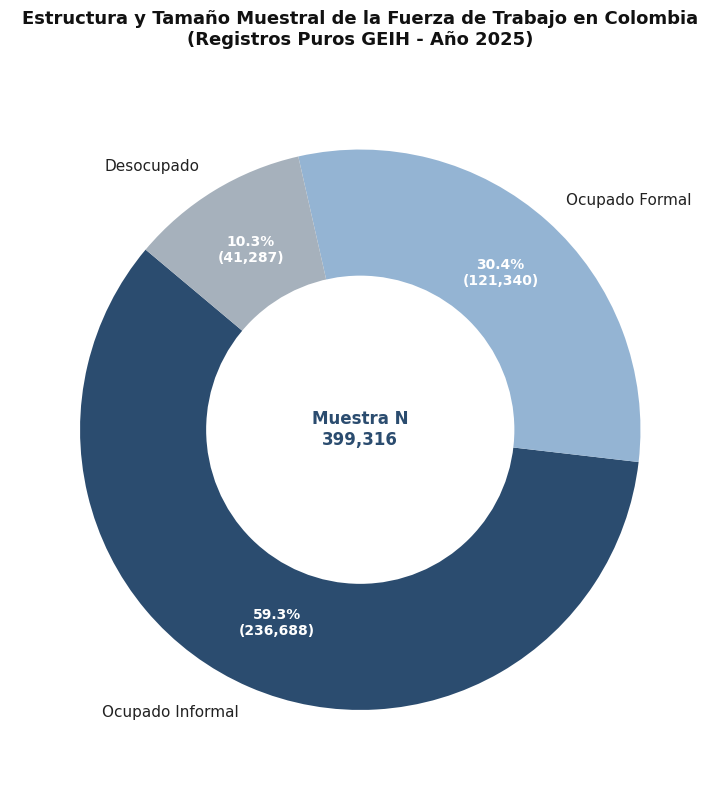

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 1. CONTEO DE REGISTROS PUROS (SIN FACTOR DE EXPANSIÓN)
# ==============================================================================
# Contamos filas directas donde Fuerza_Trabajo sea 1
df_fuerza = df_consolidado_2025[df_consolidado_2025['Fuerza_Trabajo'] == 1]
fuerza_lab_n = len(df_fuerza)

# Conteo por categorías del modelo
conteos_n = df_fuerza['Estado_Laboral'].value_counts()
informales_n = conteos_n.get('Ocupado Informal', 0)
formales_n = conteos_n.get('Ocupado Formal', 0)
desocupados_n = conteos_n.get('Desocupado', 0)

# Organizamos los datos para la gráfica
labels = ['Ocupado Informal', 'Ocupado Formal', 'Desocupado']
valores_n = [informales_n, formales_n, desocupados_n]

# ==============================================================================
# 2. CONFIGURACIÓN ESTÉTICA (TU ESTILO EXACTO)
# ==============================================================================
plt.figure(figsize=(8, 8))
colores = ['#2B4C6F', '#94B4D3', '#A6B1BC']

wedges, texts, autotexts = plt.pie(
    valores_n,
    labels=labels,
    # Formato automático: muestra el % y abajo el número absoluto de encuestados
    autopct=lambda pct: f'{pct:.1f}%\n({int(pct*fuerza_lab_n/100):,})',
    startangle=140,
    colors=colores,
    pctdistance=0.75,
    textprops=dict(color="#222222", fontsize=11)
)

# Transformación a formato dona
centro_circulo = plt.Circle((0,0), 0.55, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centro_circulo)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')

plt.title('Estructura y Tamaño Muestral de la Fuerza de Trabajo en Colombia\n(Registros Puros GEIH - Año 2025)\n',
          fontsize=13, fontweight='bold', color='#111111', pad=10)

# Texto central con el N total de la muestra analizada
plt.text(0, 0, f'Muestra N\n{fuerza_lab_n:,}', ha='center', va='center',
         fontsize=12, fontweight='bold', color='#2B4C6F')

plt.tight_layout()
plt.show()

## Resumen de Población por Situación Laboral y Sexo:

In [ ]:
# 1. Creamos una copia para no alterar la base original
df_conteo = df_consolidado_2025.copy()

# 2. Definimos la situación laboral en una nueva columna
def clasificar_situacion(valor):
    if valor == 0:
        return 'Ocupado'
    elif valor == 1:
        return 'Desempleo'
    else:
        return 'Inactivo'

df_conteo['Situacion_Laboral'] = df_conteo['desempleo'].apply(clasificar_situacion)

# 3. Mapeamos el Sexo para que la tabla sea legible
df_conteo['Sexo_Label'] = df_conteo['Sexo'].map({1: 'Hombre', 2: 'Mujer'})

# 4. Creamos la tabla cruzada (Crosstab)
tabla_resumen = pd.crosstab(
    index=df_conteo['Situacion_Laboral'],
    columns=df_conteo['Sexo_Label'],
    margins=True,
    margins_name="Total"
)

# 5. Mostramos la tabla
print("Resumen de Población por Situación Laboral y Sexo:")
display(tabla_resumen)

Resumen de Población por Situación Laboral y Sexo:


Sexo_Label,Hombre,Mujer,Total
Situacion_Laboral,,,
Desempleo,18125,23162,41287
Ocupado,199032,158997,358029
Total,217157,182159,399316


## Evolución del desempleo por mes

*Genera la Figura 4 del documento*

<Figure size 1200x600 with 0 Axes>

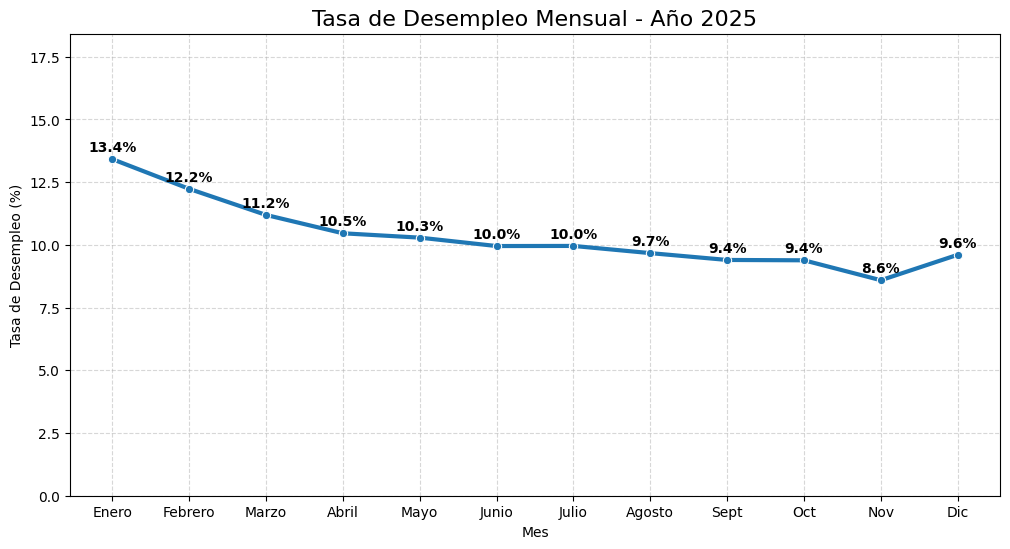

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))


nombres_meses = {
    1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril',
    5: 'Mayo', 6: 'Junio', 7: 'Julio', 8: 'Agosto',
    9: 'Sept', 10: 'Oct', 11: 'Nov', 12: 'Dic'
}

df_consolidado_2025['MES'] = pd.to_numeric(df_consolidado_2025['MES'], errors='coerce')

tasa_mensual = df_consolidado_2025.groupby('MES')['desempleo'].mean() * 100

tasa_mensual.index = tasa_mensual.index.map(nombres_meses)

# Grafica
plt.figure(figsize=(12, 6))
sns.lineplot(x=tasa_mensual.index, y=tasa_mensual.values, marker='o', color='#1f77b4', linewidth=3)

# Añadimos las etiquetas de porcentaje sobre los puntos
for i, valor in enumerate(tasa_mensual.values):
    plt.text(i, valor + 0.3, f'{valor:.1f}%', ha='center', fontweight='bold', color='black')

plt.title('Tasa de Desempleo Mensual - Año 2025', fontsize=16)
plt.ylabel('Tasa de Desempleo (%)')
plt.xlabel('Mes')
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(0, tasa_mensual.max() + 5)
plt.show()

## Tasas de desempleo por ciudades y por sexo

/tmp/ipykernel_941/1364465439.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Sexo_Label', y='Tasa_Desempleo', data=df_sexo, palette='Set2')


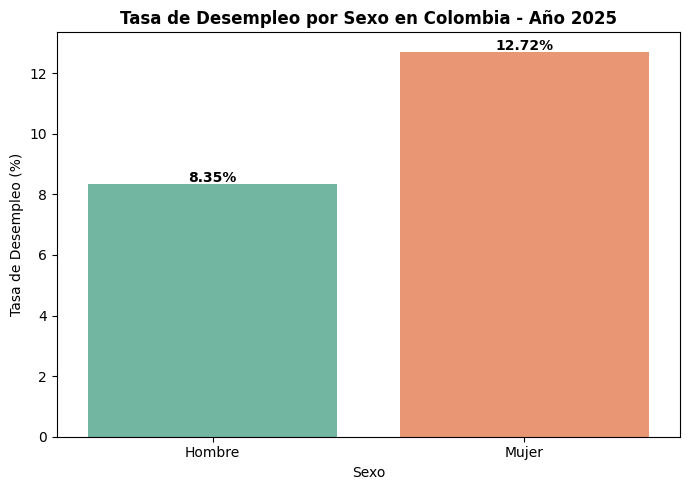

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculamos la tasa de desempleo promedio por sexo para 2025
# Asumiendo 1: Hombre, 2: Mujer (Estándar DANE, verifícalo en tu base)
df_sexo = df_consolidado_2025.groupby('Sexo')['desempleo'].mean().reset_index()
df_sexo['Tasa_Desempleo'] = df_sexo['desempleo'] * 100
df_sexo['Sexo_Label'] = df_sexo['Sexo'].map({1: 'Hombre', 2: 'Mujer'})

plt.figure(figsize=(7, 5))
ax = sns.barplot(x='Sexo_Label', y='Tasa_Desempleo', data=df_sexo, palette='Set2')
plt.title('Tasa de Desempleo por Sexo en Colombia - Año 2025', fontsize=12, fontweight='bold')
plt.ylabel('Tasa de Desempleo (%)')
plt.xlabel('Sexo')

# Añadir etiquetas de valor sobre las barras
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 0.2),
                ha='center', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
df_grafico = df_consolidado_2025.dropna(subset=['desempleo', 'Depto']).copy()

*Genera la Figura 5 del documento*

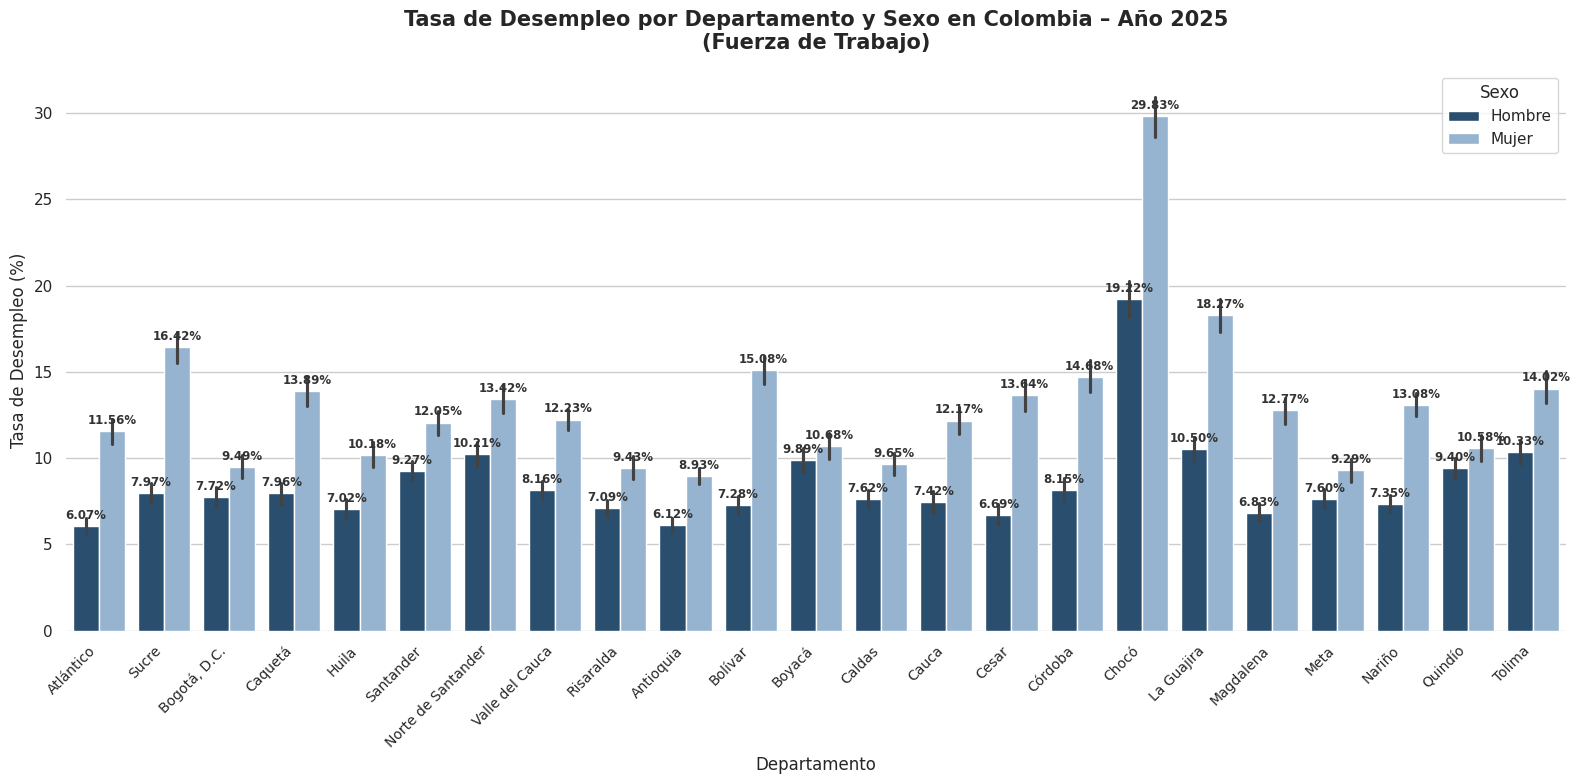

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo ejecutivo
plt.figure(figsize=(16, 8))
sns.set_theme(style="whitegrid")

# Mapeamos Sexo para que la leyenda sea clara (1: Hombre, 2: Mujer)
df_grafico['Sexo_Label'] = df_grafico['Sexo'].map({1: 'Hombre', 2: 'Mujer'})

# === NUEVA PALETA COHERENTE CON TU TFM ===
# Azul oscuro para Hombres, Azul más claro para Mujeres
paleta_sexo = {'Hombre': '#1f4e79', 'Mujer': '#8cb3d9'}
# =========================================

# Creamos el gráfico
ax = sns.barplot(
    data = df_grafico,
    x = 'Depto',
    y = 'desempleo',
    hue = 'Sexo_Label',
    palette = paleta_sexo,
    estimator = lambda x: sum(x) / len(x) * 100  # Esto calcula el % directamente
)

# Personalización limpia y profesional
plt.title('Tasa de Desempleo por Departamento y Sexo en Colombia – Año 2025\n(Fuerza de Trabajo)', fontsize=15, fontweight='bold', pad=15)
plt.ylabel('Tasa de Desempleo (%)', fontsize=12)
plt.xlabel('Departamento', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.legend(title='Sexo', loc='upper right')
sns.despine(left=True, bottom=True)

# Añadir etiquetas de valor sobre las barras con formato limpio (.2f% o .1f% según prefieras)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.2f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    xytext=(0, 3),
                    textcoords='offset points',
                    fontsize=8.5, fontweight='bold', color='#333333')

plt.tight_layout()
plt.show()

## Duración del desempleo por departamento y por sexo

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filtramos SOLO a los desempleados (quienes tienen datos de duración)
df_duracion = df_consolidado_2025[df_consolidado_2025['desempleo'] == 1].copy()

# 2. Aseguramos que la variable sea numérica y eliminamos nulos accidentales
df_duracion['Tiempo_Desempleo_Meses'] = pd.to_numeric(df_duracion['Tiempo_Desempleo_Meses'], errors = 'coerce')
df_duracion = df_duracion.dropna(subset = ['Tiempo_Desempleo_Meses', 'Depto', 'Sexo'])

# 3. Mapeo de Sexo para la leyenda
df_duracion['Sexo_Label'] = df_duracion['Sexo'].map({1: 'Hombre', 2: 'Mujer'})


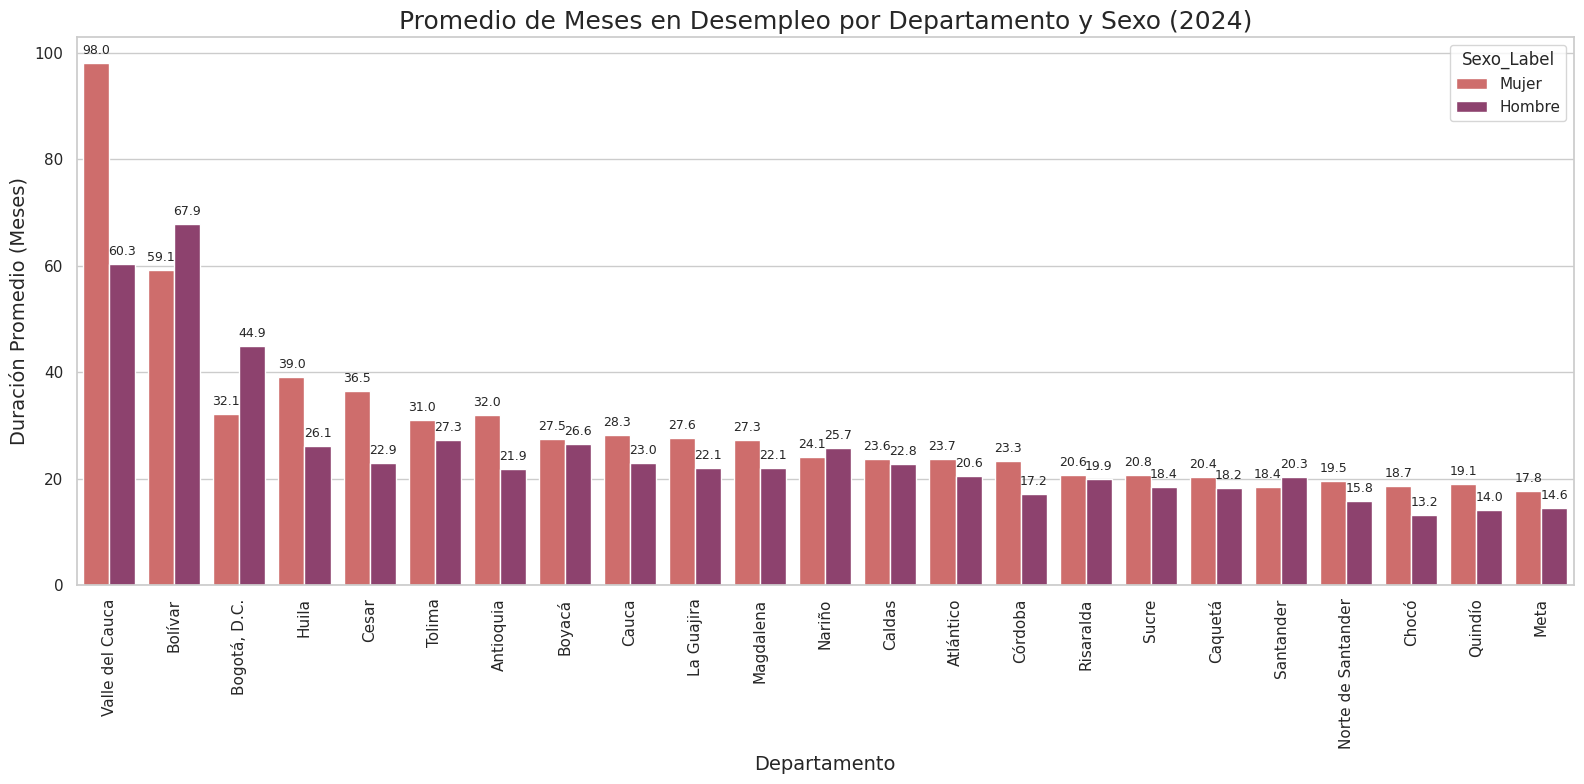

In [ ]:
plt.figure(figsize=(16, 8))
sns.set_style("whitegrid")

# Ordenamos las ciudades por el promedio de duración para que el gráfico sea más legible
orden_duracion = df_duracion.groupby('Depto')['Tiempo_Desempleo_Meses'].mean().sort_values(ascending = False).index

ax = sns.barplot(
    data = df_duracion,
    x = 'Depto',
    y = 'Tiempo_Desempleo_Meses',
    hue = 'Sexo_Label',
    order = orden_duracion,
    palette = 'flare',
    errorbar = None # Quitamos barras de error para mayor claridad visual
)

# Configuración de etiquetas
plt.title('Promedio de Meses en Desempleo por Departamento y Sexo (2024)', fontsize = 18)
plt.ylabel('Duración Promedio (Meses)', fontsize = 14)
plt.xlabel('Departamento', fontsize = 14)
plt.xticks(rotation = 90)

# Añadir etiquetas con el valor exacto sobre las barras
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha = 'center', va = 'center',
                    xytext = (0, 9), textcoords = 'offset points', fontsize = 9)

plt.tight_layout()
plt.show()

## Tasa de desempleo por ciudad y por grupo de edad

*Genera la Figura 6 del documento*

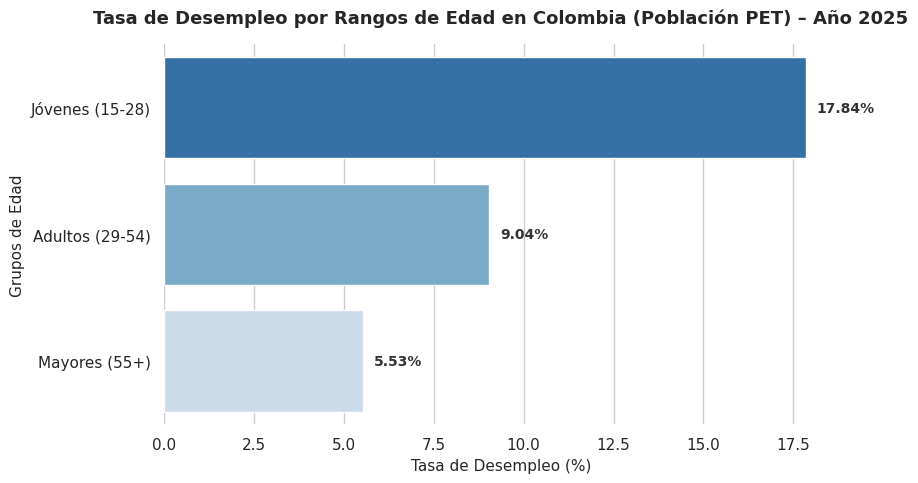

In [ ]:
# 1. Filtrar la base para conservar únicamente la Población en Edad de Trabajar
df_fuerza_trabajo_filtrada = df_consolidado_2025[df_consolidado_2025['Grupo_Edad'] != 'Menores (0-14)'].copy()

# === EL TRUCO ESTÁ AQUÍ ===
# Si la columna es de tipo 'category', obligamos a Pandas a borrar el registro en memoria de 'Menores (0-14)'
if df_fuerza_trabajo_filtrada['Grupo_Edad'].dtype.name == 'category':
    df_fuerza_trabajo_filtrada['Grupo_Edad'] = df_fuerza_trabajo_filtrada['Grupo_Edad'].cat.remove_unused_categories()
# ==========================

# 2. Recalculamos la agrupación limpia para la gráfica
df_edad_limpio = df_fuerza_trabajo_filtrada.groupby('Grupo_Edad', observed=True)['desempleo'].mean().reset_index()
df_edad_limpio['Tasa_Desempleo'] = df_edad_limpio['desempleo'] * 100

# 3. Diseño del gráfico horizontal sin menores
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")

# Dibujamos la gráfica con los datos limpios
ax = sns.barplot(
    x='Tasa_Desempleo',
    y='Grupo_Edad',
    data=df_edad_limpio.dropna(),
    palette='Blues_r',
    hue='Grupo_Edad',
    legend=False
)

plt.title('Tasa de Desempleo por Rangos de Edad en Colombia (Población PET) – Año 2025', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Tasa de Desempleo (%)', fontsize=11)
plt.ylabel('Grupos de Edad', fontsize=11)
sns.despine(left=True, bottom=True)

# Etiquetas directas al final de cada barra
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f'{width:.2f}%',
                    (width + 0.3, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center',
                    fontsize=10, fontweight='bold', color='#333333')

plt.tight_layout()
plt.show()

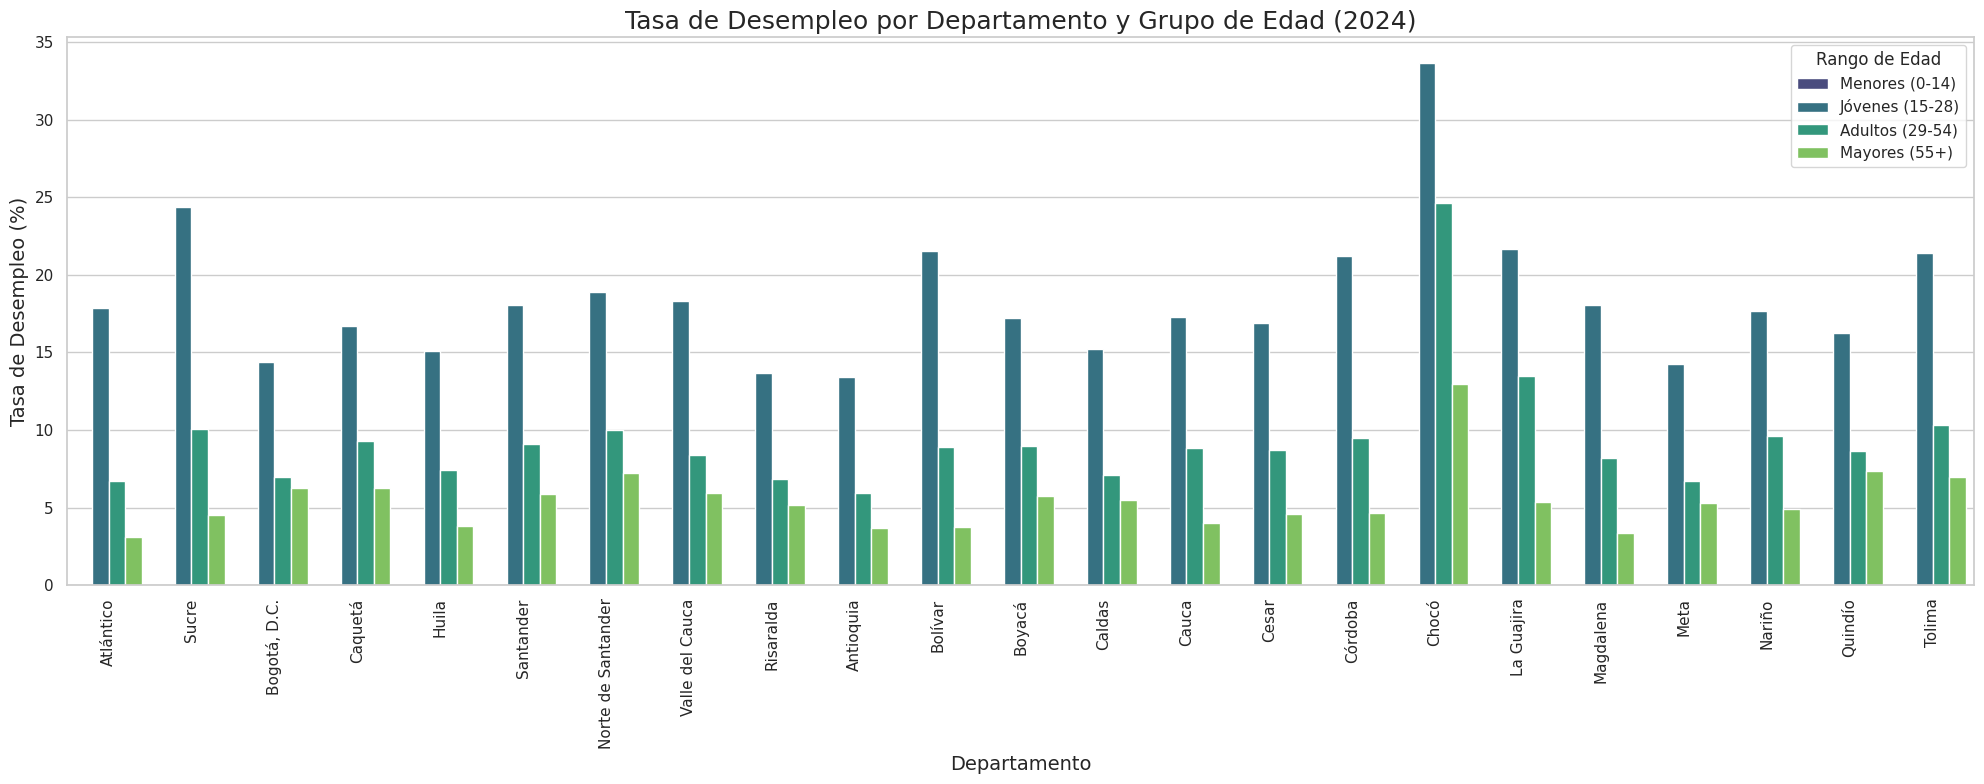

In [ ]:
plt.figure(figsize=(20, 8))
sns.set_style("whitegrid")

ax1 = sns.barplot(
    data = df_consolidado_2025,
    x = 'Depto',
    y = 'desempleo',
    hue = 'Grupo_Edad',
    estimator = lambda x: sum(x) / len(x) * 100, # Calcula el %
    palette = 'viridis',
    errorbar = None
)

plt.title('Tasa de Desempleo por Departamento y Grupo de Edad (2024)', fontsize = 18)
plt.ylabel('Tasa de Desempleo (%)', fontsize = 14)
plt.xlabel('Departamento', fontsize = 14)
plt.xticks(rotation = 90)
plt.legend(title = 'Rango de Edad', bbox_to_anchor = (1, 1))
plt.tight_layout()
plt.show()

## Duración del desempleo por ciudades y grupos de edad

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filtramos SOLO a los desempleados (quienes tienen datos de duración)
df_duracion = df_consolidado_2025[df_consolidado_2025['desempleo'] == 1].copy()

# 2. Aseguramos que la variable sea numérica y eliminamos nulos accidentales
df_duracion['Tiempo_Desempleo_Meses'] = pd.to_numeric(df_duracion['Tiempo_Desempleo_Meses'], errors = 'coerce')
df_duracion = df_duracion.dropna(subset = ['Tiempo_Desempleo_Meses', 'Depto', 'Grupo_Edad'])



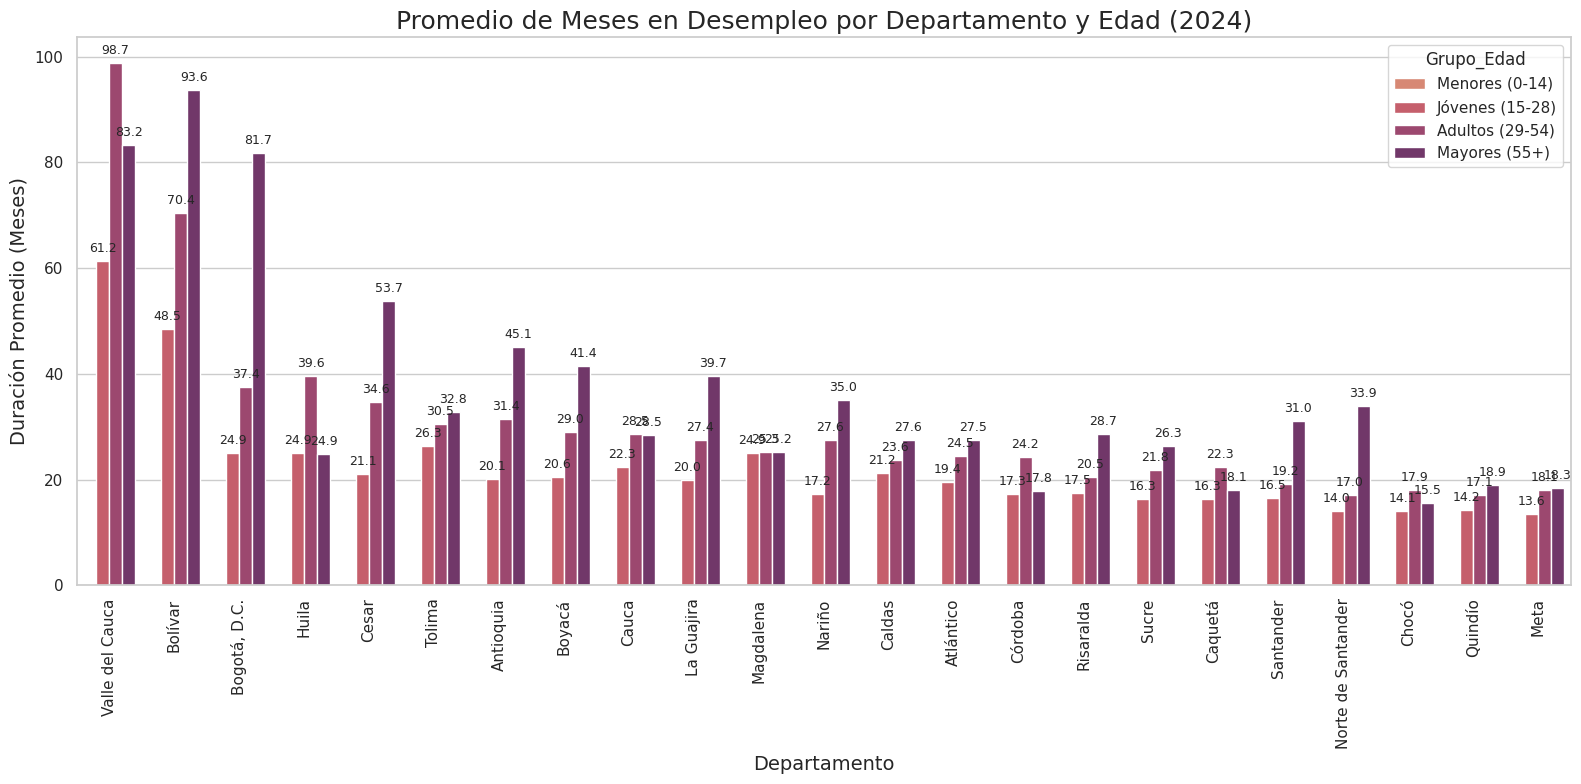

In [ ]:
plt.figure(figsize=(16, 8))
sns.set_style("whitegrid")

# Ordenamos las ciudades por el promedio de duración para que el gráfico sea más legible
orden_duracion = df_duracion.groupby('Depto')['Tiempo_Desempleo_Meses'].mean().sort_values(ascending=False).index

ax = sns.barplot(
    data = df_duracion,
    x = 'Depto',
    y = 'Tiempo_Desempleo_Meses',
    hue = 'Grupo_Edad',
    order = orden_duracion,
    palette = 'flare',
    errorbar = None # Quitamos barras de error para mayor claridad visual
)

# Configuración de etiquetas
plt.title('Promedio de Meses en Desempleo por Departamento y Edad (2024)', fontsize = 18)
plt.ylabel('Duración Promedio (Meses)', fontsize = 14)
plt.xlabel('Departamento', fontsize = 14)
plt.xticks(rotation = 90)

# Añadir etiquetas con el valor exacto sobre las barras
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha = 'center', va = 'center',
                    xytext = (0, 9), textcoords = 'offset points', fontsize = 9)

plt.tight_layout()
plt.show()

## Escolaridad

In [ ]:

print(df_consolidado_2025['Nivel_Educativo'].value_counts().sort_index())

Nivel_Educativo
Básica primaria (1o - 5o)                  65656
Básica secundaria (6o - 9o)                42085
Doctorado                                    925
Especialización                            13596
Maestría                                    6398
Media académica (Bachillerato clásico)    127621
Media técnica (Bachillerato técnico)       10473
Ninguno                                     9679
No sabe, no informa                            1
Normalista                                   616
Preescolar                                    31
Tecnológica                                17670
Técnica profesional                        38280
Universitaria                              66285
Name: count, dtype: int64


## Tasa de desempleo por ciudad y nivel de escolaridad

*Genera la figura 7 del documento*

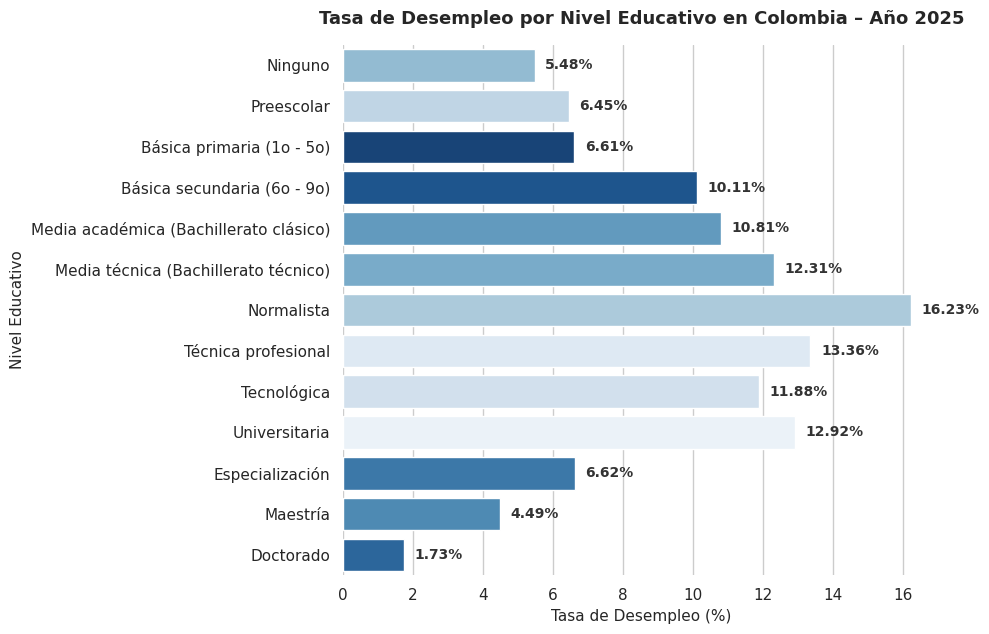

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcular la tasa de desempleo promedio por tu nueva variable homologada
df_edu_real = df_consolidado_2025.groupby('Nivel_Educativo', observed=True)['desempleo'].mean().reset_index()
df_edu_real['Tasa_Desempleo'] = df_edu_real['Tasa_Desempleo'] = df_edu_real['desempleo'] * 100

# 2. Definir el orden jerárquico lógico de la educación para el eje Y (excluyendo vacíos o "No sabe")
orden_educativo = [
    "Ninguno", "Preescolar", "Básica primaria (1o - 5o)", "Básica secundaria (6o - 9o)",
    "Media académica (Bachillerato clásico)", "Media técnica (Bachillerato técnico)",
    "Normalista", "Técnica profesional", "Tecnológica", "Universitaria",
    "Especialización", "Maestría", "Doctorado"
]

# Filtramos el dataframe temporal para asegurar que solo grafique las categorías que tengan datos y estén en el orden
df_edu_real = df_edu_real[df_edu_real['Nivel_Educativo'].isin(orden_educativo)]

# 3. Diseño del gráfico horizontal con tu estilo limpio y ejecutivo
plt.figure(figsize=(10, 6.5))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    x='Tasa_Desempleo',
    y='Nivel_Educativo',
    data=df_edu_real,
    order=orden_educativo,  # Aplica el orden jerárquico de las barras
    palette='Blues_r',
    hue='Nivel_Educativo',
    legend=False
)

# Títulos y etiquetas impecables
plt.title('Tasa de Desempleo por Nivel Educativo en Colombia – Año 2025', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Tasa de Desempleo (%)', fontsize=11)
plt.ylabel('Nivel Educativo', fontsize=11)
sns.despine(left=True, bottom=True)

# Añadir los porcentajes exactos al final de cada barra horizontal
for p in ax.patches:
    width = p.get_width()
    if width > 0:  # Evita poner etiquetas a categorías sin datos
        ax.annotate(f'{width:.2f}%',
                    (width + 0.3, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center',
                    fontsize=10, fontweight='bold', color='#333333')

plt.tight_layout()
plt.show()

# Informalidad

## Resumen informalidad

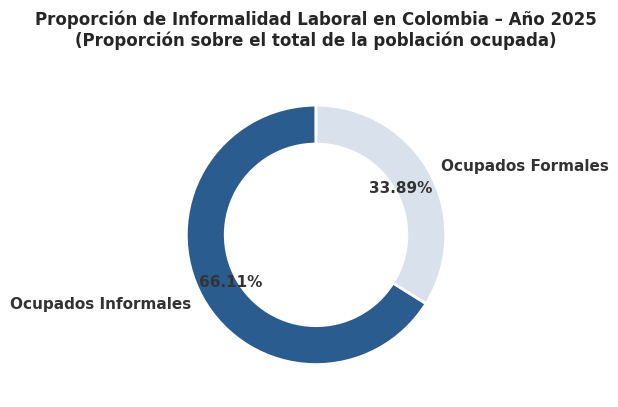

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filtrar la base: La informalidad SOLO se calcula sobre la población OCUPADA
# Ajusta 'Estado_Laboral' o la condición según tus variables (aquí asumimos que desempleo==0 son los ocupados)
df_ocupados = df_consolidado_2025[df_consolidado_2025['desempleo'] == 0].copy()

# 2. Contar cuántos son informales y cuántos formales
# Asumiendo que tu variable 'Informalidad_Final' tiene 1 para Informal y 0 para Formal
conteo_informalidad = df_ocupados['Informalidad_Final'].value_counts().reset_index()
conteo_informalidad['Label'] = conteo_informalidad['Informalidad_Final'].map({1: 'Ocupados Informales', 0: 'Ocupados Formales'})

# 3. Configuración de colores ejecutivos (Azul oscuro para formal, Gris/Azul claro para informal)
colores = ['#2b5c8f', '#d9e2ec']

# 4. Diseñar el gráfico de anillo (Donut Chart)
plt.figure(figsize=(6, 6))
sns.set_theme(style="white")

plt.pie(
    conteo_informalidad['count'],
    labels=conteo_informalidad['Label'],
    autopct='%1.2f%%',
    startangle=90,
    colors=colores,
    textprops={'fontsize': 11, 'fontweight': 'bold', 'color': '#333333'},
    pctdistance=0.75,
    wedgeprops=dict(width=0.3, edgecolor='w', linewidth=2) # Esto hace el hueco del anillo
)

# Título limpio
plt.title('Proporción de Informalidad Laboral en Colombia – Año 2025\n(Proporción sobre el total de la población ocupada)',
          fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

*Genera la figura 8 del documento*

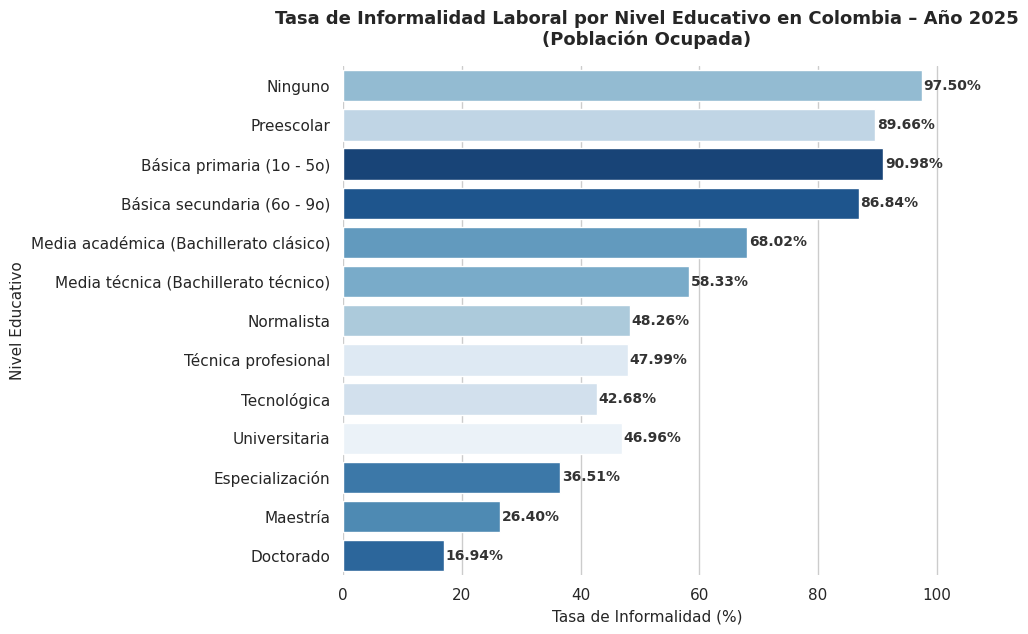

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filtramos para trabajar únicamente con la población ocupada en 2025
df_ocupados_2025 = df_consolidado_2025[df_consolidado_2025['desempleo'] == 0].copy()

# 2. Calculamos la tasa de informalidad promedio por nivel educativo
# Multiplicamos por 100 para tener el porcentaje directo
df_inf_edu = df_ocupados_2025.groupby('Nivel_Educativo', observed=True)['Informalidad_Final'].mean().reset_index()
df_inf_edu['Tasa_Informalidad'] = df_inf_edu['Informalidad_Final'] * 100

# 3. Tu orden jerárquico establecido
orden_educativo = [
    "Ninguno", "Preescolar", "Básica primaria (1o - 5o)", "Básica secundaria (6o - 9o)",
    "Media académica (Bachillerato clásico)", "Media técnica (Bachillerato técnico)",
    "Normalista", "Técnica profesional", "Tecnológica", "Universitaria",
    "Especialización", "Maestría", "Doctorado"
]

# Filtramos categorías que estén en el orden lógico
df_inf_edu = df_inf_edu[df_inf_edu['Nivel_Educativo'].isin(orden_educativo)]

# 4. Diseño del gráfico horizontal con el estilo ejecutivo que vienes usando
plt.figure(figsize=(10, 6.5))
sns.set_theme(style="whitegrid")

# Usamos una paleta inversa (Blues o Crest) para diferenciar este subcapítulo del de desempleo
ax = sns.barplot(
    x='Tasa_Informalidad',
    y='Nivel_Educativo',
    data=df_inf_edu,
    order=orden_educativo,
    palette='Blues_r',
    hue='Nivel_Educativo',
    legend=False
)

plt.title('Tasa de Informalidad Laboral por Nivel Educativo en Colombia – Año 2025\n(Población Ocupada)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Tasa de Informalidad (%)', fontsize=11)
plt.ylabel('Nivel Educativo', fontsize=11)
sns.despine(left=True, bottom=True)

# Añadir los porcentajes exactos al final de cada barra horizontal
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f'{width:.2f}%',
                    (width + 0.3, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center',
                    fontsize=10, fontweight='bold', color='#333333')

plt.tight_layout()
plt.show()

*Genera la Figura 9 del documento*

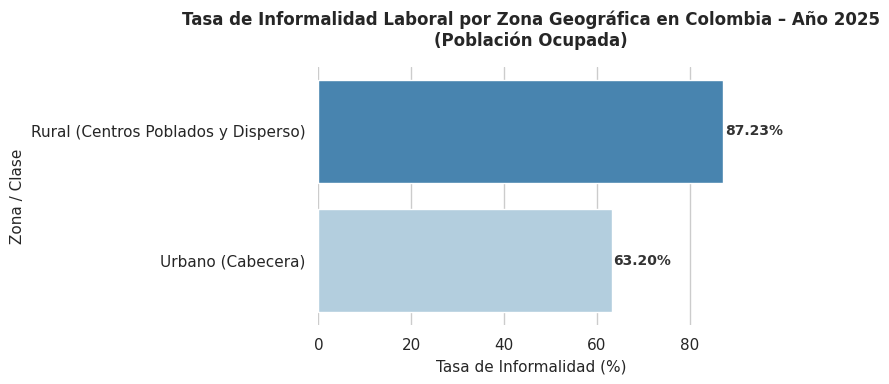

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filtramos para trabajar únicamente con la población ocupada en 2025
df_ocupados_2025 = df_consolidado_2025[df_consolidado_2025['desempleo'] == 0].copy()

# 2. Traducimos los códigos de tu variable 'Zona' (antigua CLASE)
# 1: Cabecera (Urbano), 2: Centros Poblados y Rural Disperso (Rural)
mapa_zona = {1: "Urbano (Cabecera)", 2: "Rural (Centros Poblados y Disperso)"}
df_ocupados_2025['Zona_Label'] = df_ocupados_2025['Zona'].map(mapa_zona)

# 3. Calculamos la tasa de informalidad promedio por Zona
df_inf_zona = df_ocupados_2025.groupby('Zona_Label', observed=True)['Informalidad_Final'].mean().reset_index()
df_inf_zona['Tasa_Informalidad'] = df_inf_zona['Informalidad_Final'] * 100

# Ordenamos de mayor a menor informalidad
df_inf_zona = df_inf_zona.sort_values(by='Tasa_Informalidad', ascending=False)

# 4. Diseño del gráfico horizontal minimalista
plt.figure(figsize=(8, 4))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    x='Tasa_Informalidad',
    y='Zona_Label',
    data=df_inf_zona,
    palette='Blues_r',
    hue='Zona_Label',
    legend=False
)

# Título y etiquetas al grano
plt.title('Tasa de Informalidad Laboral por Zona Geográfica en Colombia – Año 2025\n(Población Ocupada)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Tasa de Informalidad (%)', fontsize=11)
plt.ylabel('Zona / Clase', fontsize=11)
sns.despine(left=True, bottom=True)

# Añadir los porcentajes exactos al final de cada barra
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f'{width:.2f}%',
                    (width + 0.3, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center',
                    fontsize=10, fontweight='bold', color='#333333')

plt.tight_layout()
plt.show()

## Resumen del Estado laboral

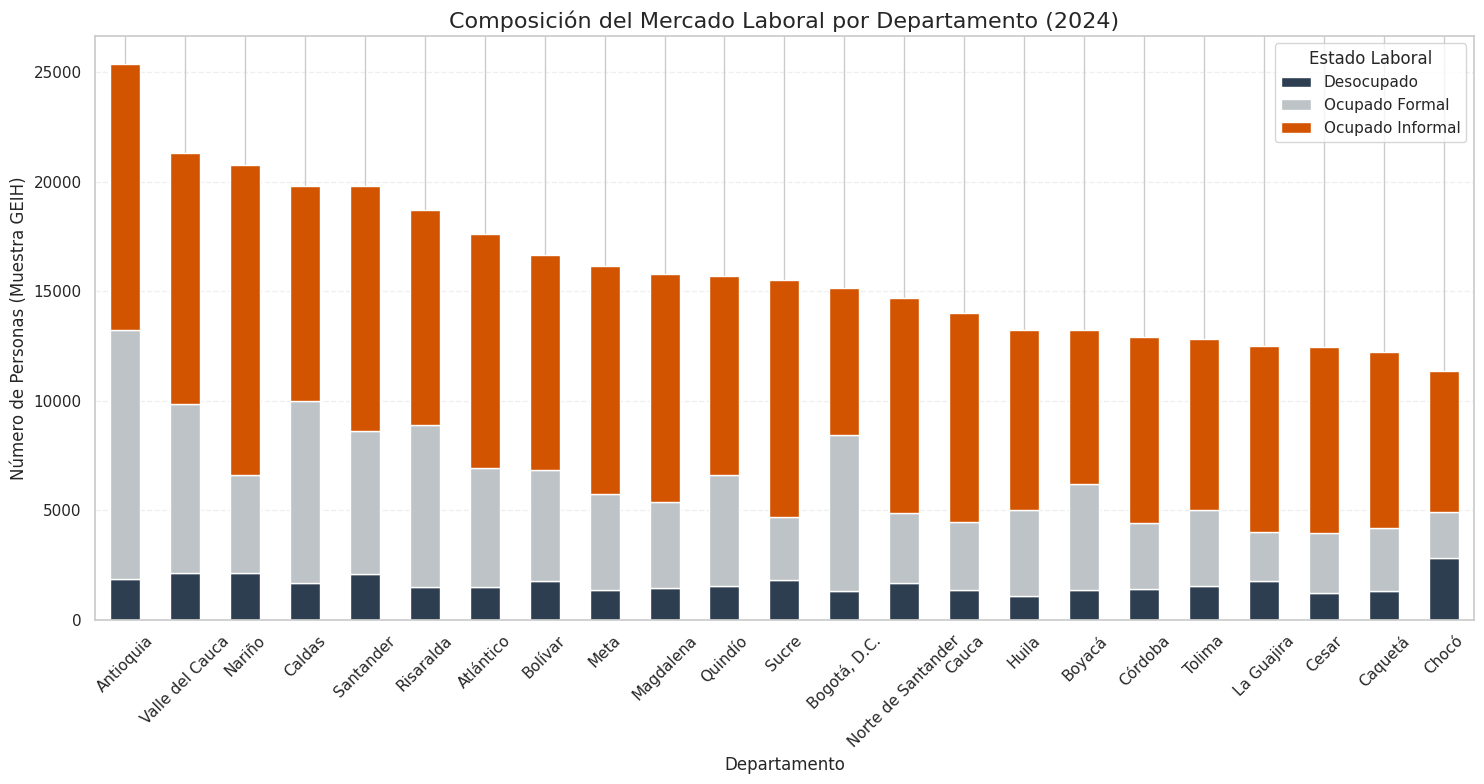

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Agrupamos por Departamento y Estado Laboral
conteo_depto = df_consolidado_2025.groupby(['Depto', 'Estado_Laboral']).size().unstack().fillna(0)

conteo_depto['Total'] = conteo_depto.sum(axis=1)
conteo_depto = conteo_depto.sort_values('Total', ascending=False).drop(columns='Total')

# Grafica
ax = conteo_depto.plot(kind='bar', stacked=True, figsize=(15, 8),
                       color=['#2c3e50', '#bdc3c7', '#d35400']) # Verde: Formal, Rojo: Desocupado, Amarillo: Informal

plt.title('Composición del Mercado Laboral por Departamento (2024)', fontsize=16)
plt.ylabel('Número de Personas (Muestra GEIH)', fontsize=12)
plt.xlabel('Departamento', fontsize=12)
plt.legend(title='Estado Laboral')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## Tipo Institucion

*Genera la Figura 10 del documento*

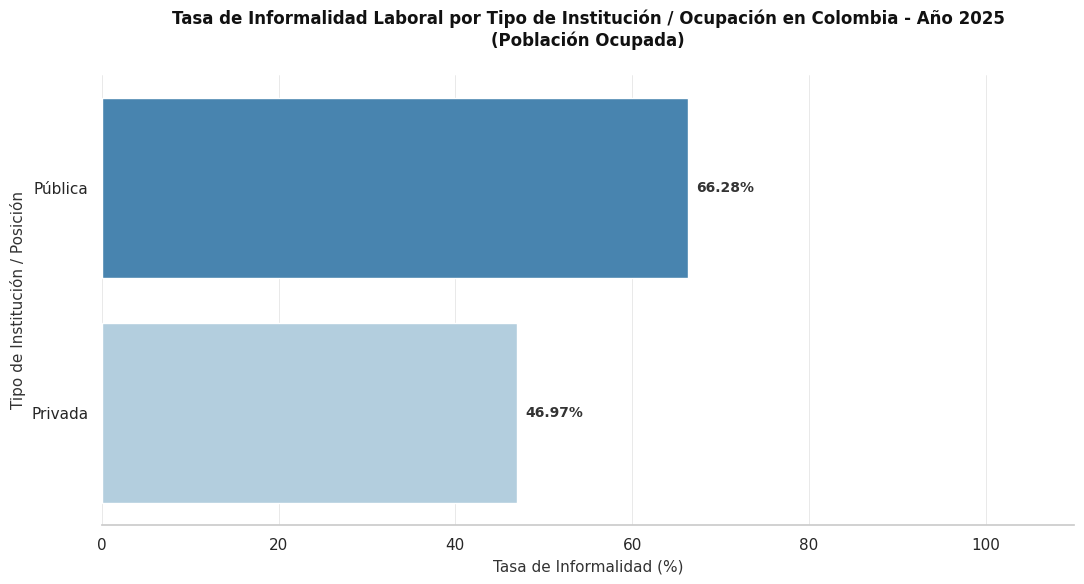


          TASAS DE INFORMALIDAD POR TIPO DE INSTITUCIÓN
 - Pública: 66.28%
 - Privada: 46.97%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ==============================================================================
# 1. FILTRO DE POBLACIÓN OCUPADA Y TABLA DE CONTINGENCIA
# ==============================================================================
# Filtramos únicamente a los que están trabajando (Formal + Informal)
df_fuerza = df_consolidado_2025[df_consolidado_2025['Fuerza_Trabajo'] == 1].copy()
df_ocupados = df_fuerza[df_fuerza['Estado_Laboral'].isin(['Ocupado Informal', 'Ocupado Formal'])].copy()

# Generamos la tabla de contingencia limpia
tabla_inst = pd.crosstab(df_ocupados['Tipo_Institucion_Nombre'], df_ocupados['Estado_Laboral'])

# Aseguramos que existan ambas columnas antes de calcular
if 'Ocupado Informal' in tabla_inst.columns and 'Ocupado Formal' in tabla_inst.columns:
    tabla_inst = tabla_inst.reindex(columns=['Ocupado Informal', 'Ocupado Formal'])
    # Calculamos la Tasa de Informalidad Oficial (%) sobre ocupados
    tabla_inst['Tasa_Informalidad'] = (tabla_inst['Ocupado Informal'] / tabla_inst.sum(axis=1)) * 100
else:
    # Alternativa por si los nombres difieren ligeramente en tu base
    tabla_inst['Tasa_Informalidad'] = (tabla_inst.iloc[:, 0] / tabla_inst.sum(axis=1)) * 100

# Ordenamos de mayor a menor informalidad para mantener tu estilo visual
tabla_inst_sorted = tabla_inst.sort_values(by='Tasa_Informalidad', ascending=False)

# ==============================================================================
# 2. CONFIGURACIÓN DE LA GRÁFICA DE BARRAS HORIZONTALES (CORREGIDA)
# ==============================================================================
plt.figure(figsize=(11, 6))

# Forzamos a que y=tabla_inst_sorted.index (texto) y x=tabla_inst_sorted['Tasa_Informalidad'] (número)
colores_barras = sns.color_palette("Blues_r", len(tabla_inst_sorted))

ax = sns.barplot(
    x=tabla_inst_sorted['Tasa_Informalidad'],
    y=tabla_inst_sorted.index,
    palette=colores_barras,
    hue=tabla_inst_sorted.index,
    legend=False
)

# Añadir los porcentajes en la punta de cada barra horizontal
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(width + 1, p.get_y() + p.get_height()/2, f'{width:.2f}%',
                va='center', ha='left', fontsize=10, fontweight='bold', color='#333333')

# Personalización estética adaptada a tu documento
plt.title('Tasa de Informalidad Laboral por Tipo de Institución / Ocupación en Colombia - Año 2025\n(Población Ocupada)\n',
          fontsize=12, fontweight='bold', color='#111111')
plt.xlabel('Tasa de Informalidad (%)', fontsize=11, color='#333333')
plt.ylabel('Tipo de Institución / Posición', fontsize=11, color='#333333')

plt.xlim(0, 110) # Damos un margen para que el texto de la barra más larga no se corte
plt.grid(axis='x', linestyle='-', linewidth=0.5, color='#e0e0e0')
plt.gca().set_axisbelow(True)
sns.despine(left=True, bottom=False)

plt.tight_layout()
plt.show()

# ==============================================================================
# 3. IMPRESIÓN DE CONTROL EN CONSOLA
# ==============================================================================
print("\n" + "="*70)
print("          TASAS DE INFORMALIDAD POR TIPO DE INSTITUCIÓN")
print("="*70)
for index, row in tabla_inst_sorted.iterrows():
    print(f" - {index}: {row['Tasa_Informalidad']:.2f}%")
print("="*70)

## Sexo


*Genera la Figura 11 del documento*

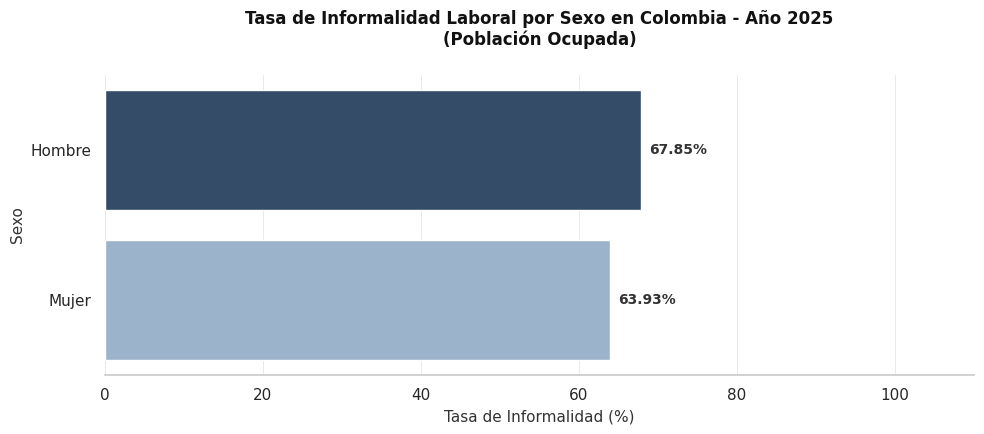


          TASAS DE INFORMALIDAD POR SEXO
 - Hombre: 67.85%
 - Mujer: 63.93%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ==============================================================================
# 1. FILTRO DE POBLACIÓN OCUPADA Y TABLA DE CONTINGENCIA MAPPED
# ==============================================================================
# Filtramos únicamente a los que están trabajando (Formal + Informal)
df_fuerza = df_consolidado_2025[df_consolidado_2025['Fuerza_Trabajo'] == 1].copy()
df_ocupados = df_fuerza[df_fuerza['Estado_Laboral'].isin(['Ocupado Informal', 'Ocupado Formal'])].copy()

# Mapeamos los códigos numéricos a texto para la presentación visual
df_ocupados['Sexo_Label'] = df_ocupados['Sexo'].map({1: 'Hombre', 2: 'Mujer'})

# Generamos la tabla de contingencia limpia
tabla_sexo = pd.crosstab(df_ocupados['Sexo_Label'], df_ocupados['Estado_Laboral'])

# Aseguramos el orden de las columnas para calcular la tasa oficial
tabla_sexo = tabla_sexo.reindex(columns=['Ocupado Informal', 'Ocupado Formal'])

# Calculamos la Tasa de Informalidad Oficial (%) sobre ocupados
tabla_sexo['Tasa_Informalidad'] = (tabla_sexo['Ocupado Informal'] / tabla_sexo.sum(axis=1)) * 100

# Ordenamos de mayor a menor informalidad
tabla_sexo_sorted = tabla_sexo.sort_values(by='Tasa_Informalidad', ascending=False)

# ==============================================================================
# 2. CONFIGURACIÓN DE LA GRÁFICA DE BARRAS HORIZONTALES (TU ESTILO)
# ==============================================================================
plt.figure(figsize=(10, 4.5))

# Usamos tus dos tonos de azul institucionales (Oscuro para la tasa más alta)
colores_barras = ['#2B4C6F', '#94B4D3']

ax = sns.barplot(
    x=tabla_sexo_sorted['Tasa_Informalidad'],
    y=tabla_sexo_sorted.index,
    palette=colores_barras,
    hue=tabla_sexo_sorted.index,
    legend=False
)

# Añadir los porcentajes en la punta de cada barra
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(width + 1, p.get_y() + p.get_height()/2, f'{width:.2f}%',
                va='center', ha='left', fontsize=10, fontweight='bold', color='#333333')

# Personalización estética
plt.title('Tasa de Informalidad Laboral por Sexo en Colombia - Año 2025\n(Población Ocupada)\n',
          fontsize=12, fontweight='bold', color='#111111')
plt.xlabel('Tasa de Informalidad (%)', fontsize=11, color='#333333')
plt.ylabel('Sexo', fontsize=11, color='#333333')

plt.xlim(0, 110)
plt.grid(axis='x', linestyle='-', linewidth=0.5, color='#e0e0e0')
plt.gca().set_axisbelow(True)
sns.despine(left=True, bottom=False)

plt.tight_layout()
plt.show()

# ==============================================================================
# 3. IMPRESIÓN DE CONTROL EN CONSOLA
# ==============================================================================
print("\n" + "="*70)
print("          TASAS DE INFORMALIDAD POR SEXO")
print("="*70)
for index, row in tabla_sexo_sorted.iterrows():
    print(f" - {index}: {row['Tasa_Informalidad']:.2f}%")
print("="*70)

## Grupos de edad

*Genera la figura 12 del documento*

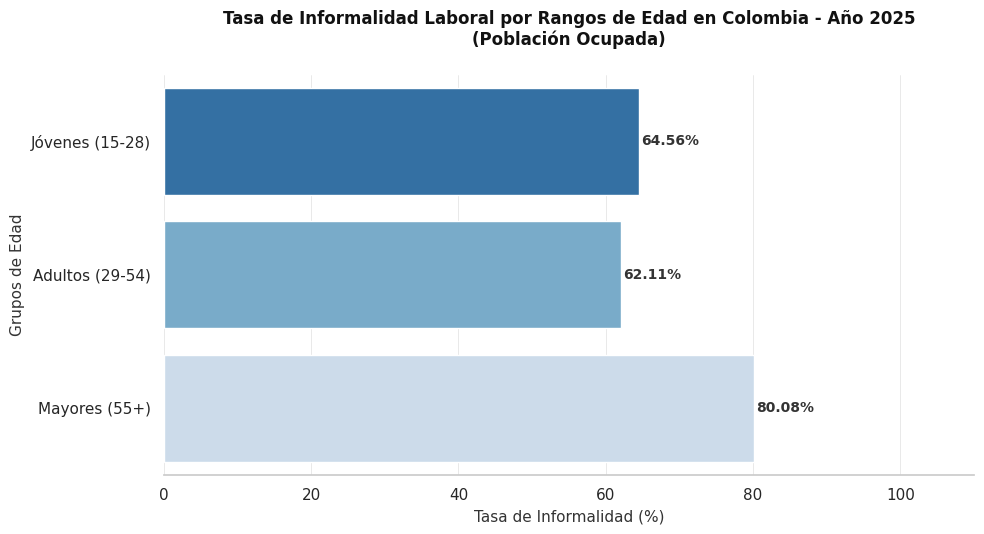

Grupo_Edad
Mayores (55+)      80.075344
Jóvenes (15-28)    64.558947
Adultos (29-54)    62.107046
Name: Tasa_Informalidad, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ==============================================================================
# FILTRO DE OCUPADOS USANDO TU COLUMNA 'Grupo_Edad'
# ==============================================================================
df_fuerza = df_consolidado_2025[df_consolidado_2025['Fuerza_Trabajo'] == 1].copy()
df_ocupados = df_fuerza[df_fuerza['Estado_Laboral'].isin(['Ocupado Informal', 'Ocupado Formal'])].copy()

# Tu truco para limpiar la categoría de Menores si viene como tipo 'category'
if df_ocupados['Grupo_Edad'].dtype.name == 'category':
    df_ocupados['Grupo_Edad'] = df_ocupados['Grupo_Edad'].cat.remove_unused_categories()

# Generamos la tabla de contingencia limpia
tabla_edad = pd.crosstab(df_ocupados['Grupo_Edad'], df_ocupados['Estado_Laboral'])
tabla_edad = tabla_edad.reindex(columns=['Ocupado Informal', 'Ocupado Formal'])

# Calculamos la Tasa de Informalidad Oficial (%) sobre ocupados
tabla_edad['Tasa_Informalidad'] = (tabla_edad['Ocupado Informal'] / tabla_edad.sum(axis=1)) * 100

# Ordenamos de mayor a menor informalidad para mantener tu estilo visual
tabla_edad_sorted = tabla_edad.sort_values(by='Tasa_Informalidad', ascending=False)

# ==============================================================================
# CONFIGURACIÓN DE LA GRÁFICA DE BARRAS HORIZONTALES (TU ESTILO)
# ==============================================================================
plt.figure(figsize=(10, 5.5))

colores_barras = sns.color_palette("Blues_r", len(tabla_edad_sorted))

ax = sns.barplot(
    x=tabla_edad_sorted['Tasa_Informalidad'],
    y=tabla_edad_sorted.index,
    palette=colores_barras,
    hue=tabla_edad_sorted.index,
    legend=False
)

# Etiquetas directas al final de cada barra horizontal
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(width + 0.3, p.get_y() + p.get_height()/2, f'{width:.2f}%',
                va='center', ha='left', fontsize=10, fontweight='bold', color='#333333')

plt.title('Tasa de Informalidad Laboral por Rangos de Edad en Colombia - Año 2025\n(Población Ocupada)\n',
          fontsize=12, fontweight='bold', color='#111111')
plt.xlabel('Tasa de Informalidad (%)', fontsize=11, color='#333333')
plt.ylabel('Grupos de Edad', fontsize=11, color='#333333')

plt.xlim(0, 110)
plt.grid(axis='x', linestyle='-', linewidth=0.5, color='#e0e0e0')
plt.gca().set_axisbelow(True)
sns.despine(left=True, bottom=False)

plt.tight_layout()
plt.show()

# Imprimir proporciones para tu control
print(tabla_edad_sorted['Tasa_Informalidad'])

## Departamento


*Genera la figura 13 del documento*

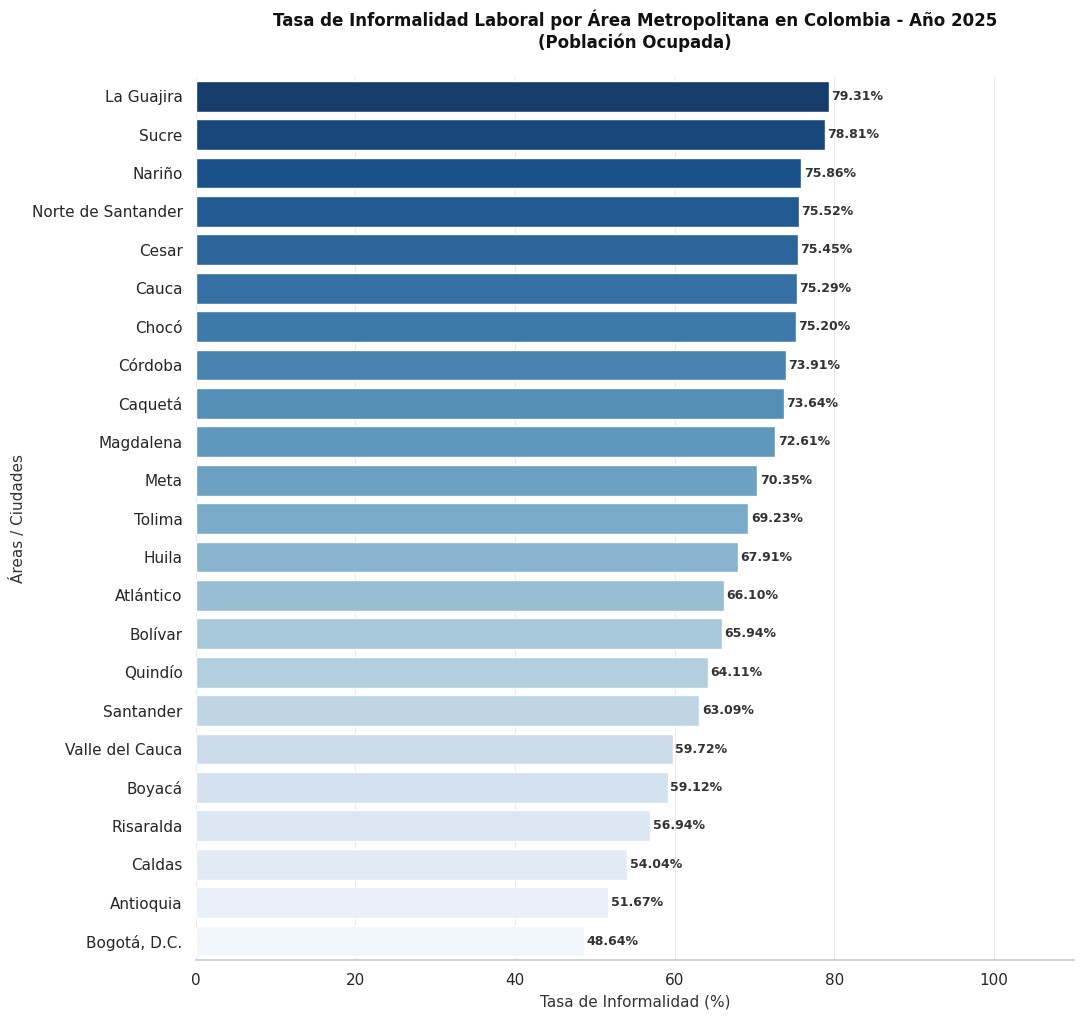


          TASAS DE INFORMALIDAD POR ÁREA METROPOLITANA
Depto
La Guajira            79.31
Sucre                 78.81
Nariño                75.86
Norte de Santander    75.52
Cesar                 75.45
Cauca                 75.29
Chocó                 75.20
Córdoba               73.91
Caquetá               73.64
Magdalena             72.61
Meta                  70.35
Tolima                69.23
Huila                 67.91
Atlántico             66.10
Bolívar               65.94
Quindío               64.11
Santander             63.09
Valle del Cauca       59.72
Boyacá                59.12
Risaralda             56.94
Caldas                54.04
Antioquia             51.67
Bogotá, D.C.          48.64
Name: Tasa_Informalidad, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ==============================================================================
# 1. FILTRO DE OCUPADOS USANDO TU COLUMNA 'AREA'
# ==============================================================================
# Filtramos únicamente a los que están trabajando (Formal + Informal)
df_fuerza = df_consolidado_2025[df_consolidado_2025['Fuerza_Trabajo'] == 1].copy()
df_ocupados = df_fuerza[df_fuerza['Estado_Laboral'].isin(['Ocupado Informal', 'Ocupado Formal'])].copy()

# Limpieza automática si viene como tipo 'category' para evitar errores
if df_ocupados['Depto'].dtype.name == 'category':
    df_ocupados['Depto'] = df_ocupados['Depto'].cat.remove_unused_categories()

# Generamos la tabla de contingencia limpia
tabla_area = pd.crosstab(df_ocupados['Depto'], df_ocupados['Estado_Laboral'])
tabla_area = tabla_area.reindex(columns=['Ocupado Informal', 'Ocupado Formal'])

# Calculamos la Tasa de Informalidad Oficial (%) sobre ocupados
tabla_area['Tasa_Informalidad'] = (tabla_area['Ocupado Informal'] / tabla_area.sum(axis=1)) * 100

# Ordenamos de mayor a menor informalidad para mantener tu estilo visual
tabla_area_sorted = tabla_area.sort_values(by='Tasa_Informalidad', ascending=False)

# ==============================================================================
# 2. CONFIGURACIÓN DE LA GRÁFICA DE BARRAS HORIZONTALES (TU ESTILO)
# ==============================================================================
# Calculamos el alto de la figura dinámicamente según el número de ciudades
alto_figura = max(6, len(tabla_area_sorted) * 0.45)
plt.figure(figsize=(11, alto_figura))

# Paleta degradada Blues_r adaptada al volumen real de áreas
colores_barras = sns.color_palette("Blues_r", len(tabla_area_sorted))

ax = sns.barplot(
    x=tabla_area_sorted['Tasa_Informalidad'],
    y=tabla_area_sorted.index,
    palette=colores_barras,
    hue=tabla_area_sorted.index,
    legend=False
)

# Etiquetas directas con el porcentaje al final de cada barra horizontal
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(width + 0.3, p.get_y() + p.get_height()/2, f'{width:.2f}%',
                va='center', ha='left', fontsize=9, fontweight='bold', color='#333333')

# Personalización estética institucional
plt.title('Tasa de Informalidad Laboral por Área Metropolitana en Colombia - Año 2025\n(Población Ocupada)\n',
          fontsize=12, fontweight='bold', color='#111111')
plt.xlabel('Tasa de Informalidad (%)', fontsize=11, color='#333333')
plt.ylabel('Áreas / Ciudades', fontsize=11, color='#333333')

plt.xlim(0, 110)
plt.grid(axis='x', linestyle='-', linewidth=0.5, color='#e0e0e0')
plt.gca().set_axisbelow(True)
sns.despine(left=True, bottom=False)

plt.tight_layout()
plt.show()

# ==============================================================================
# 3. IMPRESIÓN DE CONTROL EN CONSOLA
# ==============================================================================
print("\n" + "="*70)
print("          TASAS DE INFORMALIDAD POR ÁREA METROPOLITANA")
print("="*70)
print(tabla_area_sorted['Tasa_Informalidad'].round(2))
print("="*70)

## Jefe de Hogar

*Genera la Figura 14 del documento*

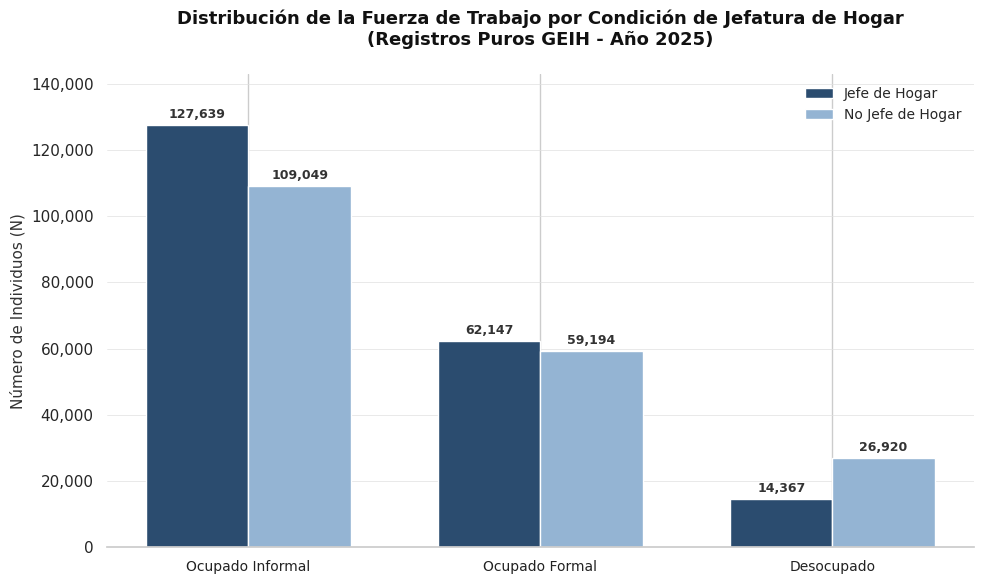


          PORCENTAJES DE DISTRIBUCIÓN PARA EL TEXTO DEL INFORME

Distribución interna para NO JEFES DE HOGAR (Total N = 195,163):
 - Ocupado Informal: 109,049 registros (55.88%)
 - Ocupado Formal: 59,194 registros (30.33%)
 - Desocupado: 26,920 registros (13.79%)

Distribución interna para JEFES DE HOGAR (Total N = 204,153):
 - Ocupado Informal: 127,639 registros (62.52%)
 - Ocupado Formal: 62,147 registros (30.44%)
 - Desocupado: 14,367 registros (7.04%)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ==============================================================================
# 1. EXTRACCIÓN AUTOMÁTICA DE REGISTROS (MUESTRA PURA N)
# ==============================================================================
# Filtramos la población activa (Fuerza_Trabajo == 1)
df_fuerza = df_consolidado_2025[df_consolidado_2025['Fuerza_Trabajo'] == 1].copy()

# Creamos la tabla de contingencia cruzando Estado Laboral y Jefatura de Hogar
# Suponiendo que jefe_hogar_1 tiene valores: 1 (Es Jefe) y 0 (No es Jefe)
tabla_jefatura = pd.crosstab(df_fuerza['Estado_Laboral'], df_fuerza['jefe_Hogar'])

# Ordenamos las filas para mantener consistencia en los análisis
categorias_orden = ['Ocupado Informal', 'Ocupado Formal', 'Desocupado']
tabla_jefatura = tabla_jefatura.reindex(categorias_orden)

# Extraemos los valores para graficar
jefes = tabla_jefatura[1].tolist()
no_jefes = tabla_jefatura[0].tolist()

# ==============================================================================
# 2. CONFIGURACIÓN GRÁFICA (TU ESTILO EXACTO)
# ==============================================================================
plt.figure(figsize=(10, 6))

# Paleta institucional de tu tesis
color_jefe = '#2B4C6F'      # Azul oscuro
color_no_jefe = '#94B4D3'   # Azul claro

x = range(len(categorias_orden))
width = 0.35  # Ancho de las barras

# Dibujamos las barras agrupadas
barras_jefe = plt.bar([i - width/2 for i in x], jefes, width, label='Jefe de Hogar', color=color_jefe)
barras_no_jefe = plt.bar([i + width/2 for i in x], no_jefes, width, label='No Jefe de Hogar', color=color_no_jefe)

# Añadir etiquetas de datos sobre cada barra (Frecuencia absoluta e indicación visual)
for barra in barras_jefe:
    height = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2., height + (max(jefes+no_jefes)*0.01),
             f'{height:,}', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#333333')

for barra in barras_no_jefe:
    height = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2., height + (max(jefes+no_jefes)*0.01),
             f'{height:,}', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#333333')

# Personalización estética institucional
plt.title('Distribución de la Fuerza de Trabajo por Condición de Jefatura de Hogar\n(Registros Puros GEIH - Año 2025)\n',
          fontsize=13, fontweight='bold', color='#111111')
plt.ylabel('Número de Individuos (N)', fontsize=11, color='#333333')
plt.xticks(x, categorias_orden, fontsize=10, color='#222222')

# Formato del eje Y con separadores de miles
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
plt.ylim(0, max(jefes+no_jefes) * 1.12)

# Cuadrícula sutil y despine estilo DANE
plt.grid(axis='y', linestyle='-', linewidth=0.5, color='#e0e0e0', zorder=0)
plt.gca().set_axisbelow(True)
sns.despine(left=True, bottom=False)
plt.gca().spines['bottom'].set_color('#cccccc')

plt.legend(frameon=False, loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

# ==============================================================================
# 3. IMPRESIÓN DE PORCENTAJES PARA LA REDACCIÓN
# ==============================================================================
print("\n" + "="*70)
print("          PORCENTAJES DE DISTRIBUCIÓN PARA EL TEXTO DEL INFORME")
print("="*70)
for col in tabla_jefatura.columns:
    tipo = "JEFES DE HOGAR" if col == 1 else "NO JEFES DE HOGAR"
    total_tipo = tabla_jefatura[col].sum()
    print(f"\nDistribución interna para {tipo} (Total N = {total_tipo:,}):")
    for cat in categorias_orden:
        val = tabla_jefatura.loc[cat, col]
        print(f" - {cat}: {val:,} registros ({(val/total_tipo)*100:.2f}%)")
print("="*70)

## Estado Civil

*Genera la figura 15 del documento*

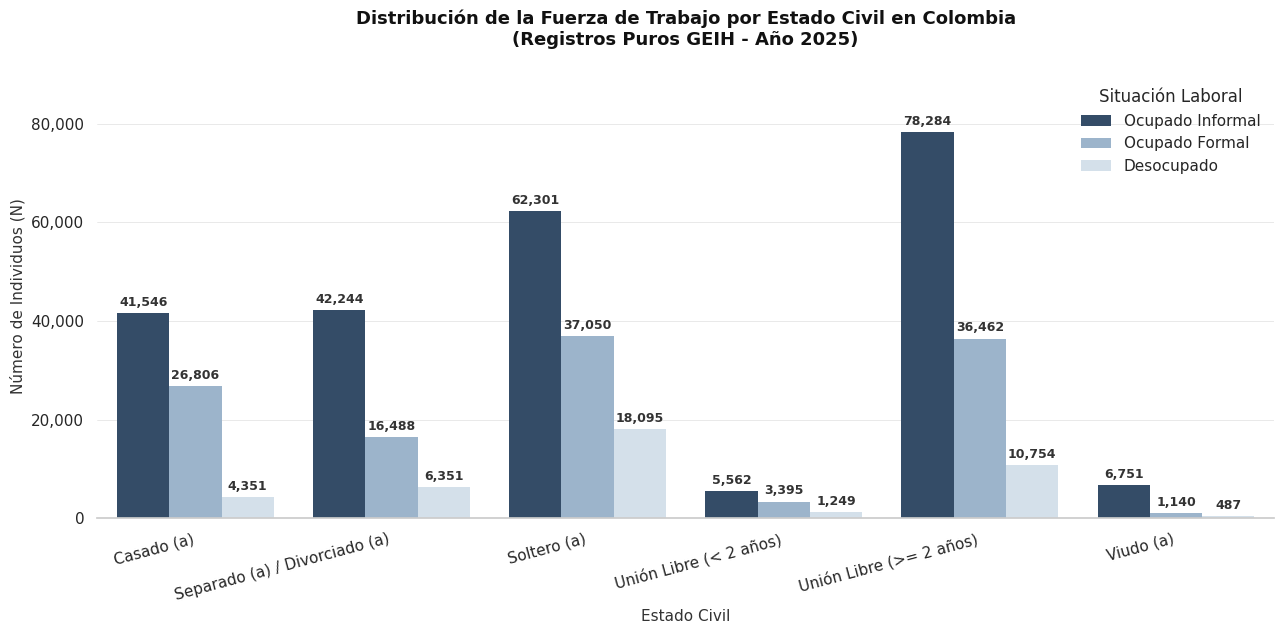


          TABLA DE CONTROL DE FRECUENCIAS
Estado_Laboral                 Ocupado Informal  Ocupado Formal  Desocupado
Estado_Civil_Label                                                         
Casado (a)                                41546           26806        4351
Separado (a) / Divorciado (a)             42244           16488        6351
Soltero (a)                               62301           37050       18095
Unión Libre (< 2 años)                     5562            3395        1249
Unión Libre (>= 2 años)                   78284           36462       10754
Viudo (a)                                  6751            1140         487


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ==============================================================================
# 1. FILTRO DE LA FUERZA DE TRABAJO Y MAPEO DE ESTADO CIVIL
# ==============================================================================
# Filtramos la población activa (Ocupados + Desocupados)
df_fuerza = df_consolidado_2025[df_consolidado_2025['Fuerza_Trabajo'] == 1].copy()

# Diccionario basado en la imagen image_ce7547.png con etiquetas optimizadas para gráficos
dicc_civil = {
    1: 'Unión Libre (< 2 años)',
    2: 'Unión Libre (>= 2 años)',
    3: 'Casado (a)',
    4: 'Separado (a) / Divorciado (a)',
    5: 'Viudo (a)',
    6: 'Soltero (a)'
}

# Mapeamos la variable numérica a las etiquetas de texto
df_fuerza['Estado_Civil_Label'] = df_fuerza['Estado_Civil'].map(dicc_civil)

# Limpieza de categorías vacías en caso de que sea tipo category
if df_fuerza['Estado_Civil_Label'].dtype.name == 'category':
    df_fuerza['Estado_Civil_Label'] = df_fuerza['Estado_Civil_Label'].cat.remove_unused_categories()

# Generamos la tabla de frecuencias (Filas: Estado Civil | Columnas: Estado Laboral)
tabla_civil = pd.crosstab(df_fuerza['Estado_Civil_Label'], df_fuerza['Estado_Laboral'])

# Aseguramos el orden de las columnas para mantener la misma estructura visual
categorias_laborales = ['Ocupado Informal', 'Ocupado Formal', 'Desocupado']
tabla_civil = tabla_civil.reindex(columns=categorias_laborales).dropna(how='all')

# Convertimos a formato largo para Seaborn
df_grafico = tabla_civil.reset_index().melt(id_vars='Estado_Civil_Label', value_name='Conteo')

# ==============================================================================
# 2. CONFIGURACIÓN DE LA GRÁFICA DE BARRAS AGRUPADAS (TU ESTILO)
# ==============================================================================
plt.figure(figsize=(13, 6.5))

# Manteniendo tu paleta institucional de azules
colores_laborales = {
    'Ocupado Informal': '#2B4C6F',  # Azul oscuro
    'Ocupado Formal': '#94B4D3',    # Azul claro
    'Desocupado': '#D1E0ED'         # Azul muy claro
}

ax = sns.barplot(
    x='Estado_Civil_Label',
    y='Conteo',
    hue='Estado_Laboral',
    data=df_grafico,
    palette=colores_laborales,
    edgecolor='none'
)

# Añadir las etiquetas de conteo encima de cada barra
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height):,}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=9, fontweight='bold', color='#333333',
                    xytext=(0, 3), textcoords='offset points')

# Personalización estética
plt.title('Distribución de la Fuerza de Trabajo por Estado Civil en Colombia\n(Registros Puros GEIH - Año 2025)\n',
          fontsize=13, fontweight='bold', color='#111111')
plt.xlabel('Estado Civil', fontsize=11, color='#333333')
plt.ylabel('Número de Individuos (N)', fontsize=11, color='#333333')

plt.ylim(0, df_grafico['Conteo'].max() * 1.15)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.grid(axis='y', linestyle='-', linewidth=0.5, color='#e0e0e0')
plt.gca().set_axisbelow(True)
plt.xticks(rotation=15, ha='right') # Rotación suave para leer bien las uniones libres
sns.despine(left=True, bottom=False)

plt.legend(title='Situación Laboral', frameon=False, loc='upper right')

plt.tight_layout()
plt.show()

# ==============================================================================
# 3. TABLA DE CONTROL PARA PORCENTAJES EN EL ANÁLISIS
# ==============================================================================
print("\n" + "="*80)
print("          TABLA DE CONTROL DE FRECUENCIAS")
print("="*80)
print(tabla_civil)
print("="*80)

## Estrato


*Genera la figura 16 del documento*

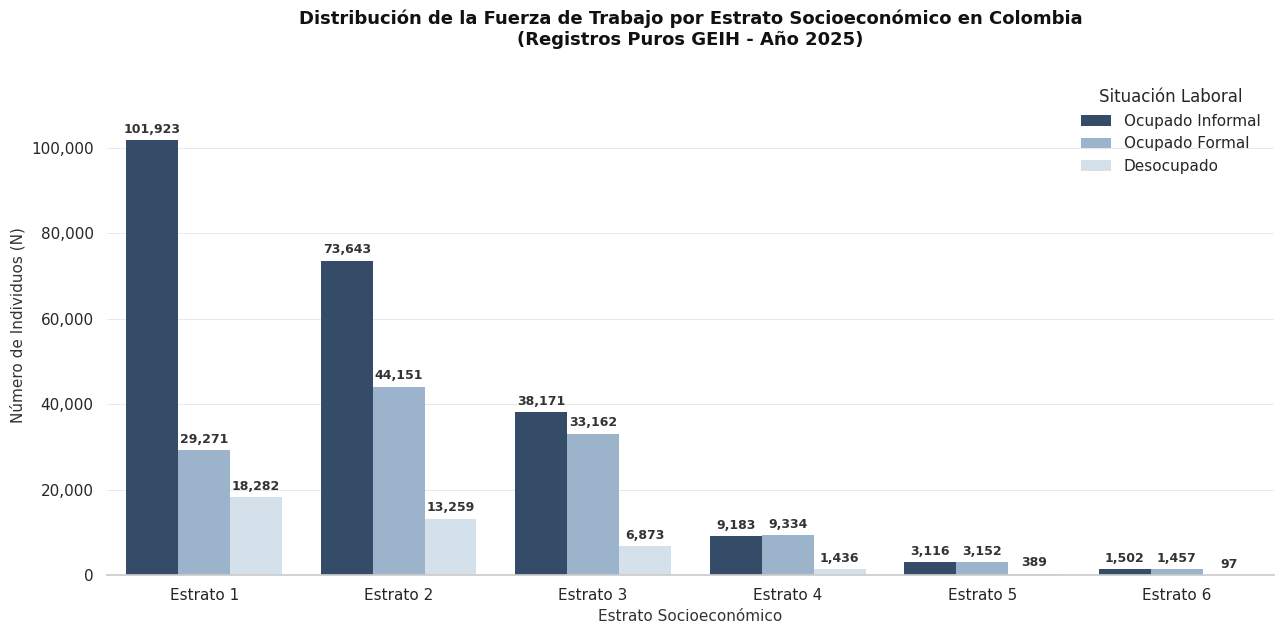


          TABLA DE CONTROL DE FRECUENCIAS POR ESTRATO
Estado_Laboral  Ocupado Informal  Ocupado Formal  Desocupado
Estrato_Label                                               
Estrato 1                 101923           29271       18282
Estrato 2                  73643           44151       13259
Estrato 3                  38171           33162        6873
Estrato 4                   9183            9334        1436
Estrato 5                   3116            3152         389
Estrato 6                   1502            1457          97


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ==============================================================================
# 1. FILTRO DE LA FUERZA DE TRABAJO Y CONVERSIÓN DE ESTRATO
# ==============================================================================
# Filtramos la población activa (Ocupados + Desocupados)
df_fuerza = df_consolidado_2025[df_consolidado_2025['Fuerza_Trabajo'] == 1].copy()

# Nos aseguramos de conservar solo los estratos válidos del 1 al 6
df_fuerza = df_fuerza[df_fuerza['Estrato'].isin([1, 2, 3, 4, 5, 6])].copy()

# Convertimos el número a una etiqueta limpia para el eje X
df_fuerza['Estrato_Label'] = df_fuerza['Estrato'].astype(int).apply(lambda x: f'Estrato {x}')

# Generamos la tabla de frecuencias (Filas: Estrato | Columnas: Estado Laboral)
tabla_estrato = pd.crosstab(df_fuerza['Estrato_Label'], df_fuerza['Estado_Laboral'])

# Aseguramos el orden de las columnas para mantener tu identidad visual
categorias_laborales = ['Ocupado Informal', 'Ocupado Formal', 'Desocupado']
tabla_estrato = tabla_estrato.reindex(columns=categorias_laborales).dropna(how='all')

# Forzamos el orden del eje X del Estrato 1 al Estrato 6
orden_estratos = ['Estrato 1', 'Estrato 2', 'Estrato 3', 'Estrato 4', 'Estrato 5', 'Estrato 6']
tabla_estrato = tabla_estrato.reindex(orden_estratos)

# Convertimos a formato largo (long format) para Seaborn
df_grafico = tabla_estrato.reset_index().melt(id_vars='Estrato_Label', value_name='Conteo')

# ==============================================================================
# 2. CONFIGURACIÓN DE LA GRÁFICA DE BARRAS VERTICALES AGRUPADAS
# ==============================================================================
plt.figure(figsize=(13, 6.5))

# Tus tres azules institucionales seleccionados para cada situación laboral
colores_laborales = {
    'Ocupado Informal': '#2B4C6F',  # Azul oscuro
    'Ocupado Formal': '#94B4D3',    # Azul claro
    'Desocupado': '#D1E0ED'         # Azul muy claro / grisáceo
}

ax = sns.barplot(
    x='Estrato_Label',
    y='Conteo',
    hue='Estado_Laboral',
    data=df_grafico,
    palette=colores_laborales,
    edgecolor='none'
)

# Añadir las etiquetas de conteo puro encima de cada barra vertical
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height):,}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=9, fontweight='bold', color='#333333',
                    xytext=(0, 3), textcoords='offset points')

# Personalización estética adaptada al resto de tus capítulos
plt.title('Distribución de la Fuerza de Trabajo por Estrato Socioeconómico en Colombia\n(Registros Puros GEIH - Año 2025)\n',
          fontsize=13, fontweight='bold', color='#111111')
plt.xlabel('Estrato Socioeconómico', fontsize=11, color='#333333')
plt.ylabel('Número de Individuos (N)', fontsize=11, color='#333333')

# Margen superior para que los números de las barras no se corten con el marco
plt.ylim(0, df_grafico['Conteo'].max() * 1.15)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.grid(axis='y', linestyle='-', linewidth=0.5, color='#e0e0e0')
plt.gca().set_axisbelow(True)
sns.despine(left=True, bottom=False)

# Leyenda limpia y bien posicionada
plt.legend(title='Situación Laboral', frameon=False, loc='upper right')

plt.tight_layout()
plt.show()

# ==============================================================================
# 3. TABLA DE CONTROL PARA EL ANÁLISIS
# ==============================================================================
print("\n" + "="*80)
print("          TABLA DE CONTROL DE FRECUENCIAS POR ESTRATO")
print("="*80)
print(tabla_estrato)
print("="*80)

# Tratamiento de valores nulos

In [ ]:
import pandas as pd

# 1. Extraemos dinámicamente todos los nombres nuevos de tus variables
variables_en_espanol = list(diccionario_renombre.values())

# Añadimos las variables calculadas que creamos en los pasos anteriores si existen
for var_extra in ['Depto', 'Estado_Laboral']:
    if var_extra in df_consolidado_2025.columns:
        variables_en_espanol.append(var_extra)

# 2. Filtramos la lista para asegurarnos de medir solo las que realmente están en el DataFrame
vars_presentes = [v for v in variables_en_espanol if v in df_consolidado_2025.columns]

# 3. Calculamos la cantidad absoluta y el porcentaje de datos faltantes
conteo_nulos = df_consolidado_2025[vars_presentes].isnull().sum()
porcentaje_nulos = df_consolidado_2025[vars_presentes].isnull().mean() * 100

# 4. Consolidamos en un DataFrame de diagnóstico estructurado
reporte_nulos_completo = pd.DataFrame({
    'Registros Faltantes (Cant)': conteo_nulos,
    'Porcentaje Faltantes (%)': porcentaje_nulos
}).sort_values(by='Porcentaje Faltantes (%)', ascending=False)

print("============ DIAGNÓSTICO DE DATOS FALTANTES (GEIH 2024) ============")
print(f"Total de registros analizados: {len(df_consolidado_2025):,}")
print("====================================================================")
print(reporte_nulos_completo.round(2))

============ DIAGNÓSTICO DE DATOS FALTANTES (GEIH 2024) ============
Total de registros analizados: 399,316
                        Registros Faltantes (Cant)  Porcentaje Faltantes (%)
Fuera_Fuerza_Trabajo                        399316                    100.00
Valor_Cuota                                 383682                     96.08
Tipo_Institucion                            378542                     94.80
Oficio_ult_Trabajo                          363737                     91.09
Tamaño_Empresa_Ant                          363737                     91.09
Desocupado_Sin_Ingreso                      358029                     89.66
Tiempo_Desempleo_Meses                      358029                     89.66
Termino_Contrato                            258898                     64.84
Quien_Paga_Pension                          248391                     62.20
Fondo_Pension                               248391                     62.20
Valor_Arriendo                              2